# Dependencies

In [ ]:
pip install chromadb

# Load set

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import chromadb
from chromadb.config import Settings
import numpy as np
import pandas as pd

CHROMA_DB_PATH = '/content/drive/MyDrive/ribbit/chromadb'

client = chromadb.PersistentClient(
    path=CHROMA_DB_PATH,
    settings=Settings(anonymized_telemetry=False)
)

collection = client.get_collection(name="anuraset_singlecall")
print(f"✓ Collection loaded: {collection.count()} embeddings")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Collection loaded: 19282 embeddings


In [ ]:
results = collection.get(include=['embeddings', 'metadatas'])
embeddings = np.array(results['embeddings'])
metadata_df = pd.DataFrame(results['metadatas'])
metadata_df['date'] = pd.to_datetime(metadata_df['date'])
metadata_df['month'] = metadata_df['date'].dt.month
metadata_df['is_wet_season'] = metadata_df['month'].apply(
    lambda m: 1 if m in [10, 11, 12, 1, 2, 3] else 0
)
metadata_df.drop(columns=['month'], inplace=True)

In [ ]:
print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Metadata shape:   {metadata_df.shape}")
metadata_df.head()


Embeddings shape: (19282, 1024)
Metadata shape:   (19282, 7)


,site,date,fname,max_t,min_t,species,is_wet_season
0,INCT20955,2019-09-09 05:00:00,INCT20955_20190909_050000,3.0,0.0,SCIPER,0
1,INCT20955,2019-09-09 05:00:00,INCT20955_20190909_050000,33.0,30.0,SCIPER,0
2,INCT20955,2019-09-09 05:00:00,INCT20955_20190909_050000,40.0,37.0,SCIPER,0
3,INCT20955,2019-09-09 05:00:00,INCT20955_20190909_050000,41.0,38.0,SCIPER,0
4,INCT20955,2019-09-09 05:00:00,INCT20955_20190909_050000,42.0,39.0,SCIPER,0


# Attempt on K-Means

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

singlespecies = pd.read_csv('/content/drive/MyDrive/ribbit/chromadb/singlespecies.csv')
season = metadata_df['is_wet_season'].values.reshape(-1, 1)
metadata_df['site_code'] = pd.Categorical(metadata_df['site']).codes
site   = metadata_df['site_code'].values.reshape(-1, 1)

In [ ]:
from sklearn.model_selection import train_test_split

species_counts = metadata_df['species'].value_counts()
valid_species = species_counts[species_counts >= 100].index

print(f"Species before filter: {metadata_df['species'].nunique()}")
mask = metadata_df['species'].isin(valid_species)
metadata_filtered = metadata_df[mask].reset_index(drop=True)
X_filtered = embeddings[mask]
print(f"Species after filter:  {metadata_filtered['species'].nunique()}")
print(f"Samples after filter:  {len(metadata_filtered)}")

train_idx, test_idx = train_test_split(
    metadata_filtered.index,
    test_size=0.2,
    random_state=42,
    stratify=metadata_filtered['species']
)

X_train = X_filtered[train_idx]
X_test  = X_filtered[test_idx]
meta_train = metadata_filtered.loc[train_idx].reset_index(drop=True)
meta_test  = metadata_filtered.loc[test_idx].reset_index(drop=True)


print(f"\nTrain: {X_train.shape}")
print(f"Test:  {X_test.shape}")
#print(f"\nSmallest species in train: {meta_train['species'].value_counts().min()} samples")
#print(f"Smallest species in test:  {meta_test['species'].value_counts().min()} samples")

# Balance check
#print(f"\nSpecies distribution in train:")
#print(meta_train['species'].value_counts())
#print(f"\nSpecies distribution in test:")
#print(meta_test['species'].value_counts())

Species before filter: 34
Species after filter:  22
Samples after filter:  18951

Train: (15160, 1024)
Test:  (3791, 1024)

Species distribution in train:
species
BOAALB    2135
BOAFAB    2053
BOABIS    2010
SPHSUR    1415
LEPPOD     930
PHYCUV     786
BOALUN     680
PHYALB     639
PITAZU     618
DENMIN     603
LEPNOT     574
BOAALM     506
LEPFUS     450
PHYDIS     386
ADEMAR     312
DENCRU     242
LEPLAT     230
PHYMAR     149
PHYSAU     124
ADEDIP     116
SCIPER     111
DENNAN      91
Name: count, dtype: int64

Species distribution in test:
species
BOAALB    534
BOAFAB    513
BOABIS    502
SPHSUR    354
LEPPOD    232
PHYCUV    196
BOALUN    170
PHYALB    160
PITAZU    155
DENMIN    151
LEPNOT    144
BOAALM    126
LEPFUS    113
PHYDIS     96
ADEMAR     78
DENCRU     61
LEPLAT     58
PHYMAR     37
PHYSAU     31
ADEDIP     29
SCIPER     28
DENNAN     23
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans

k = meta_train['species'].nunique()
print(f"\nFitting k-means with k={k} on train set...")

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
meta_train['cluster'] = kmeans.fit_predict(X_train)
print(f"Done! Inertia: {kmeans.inertia_:.2f}")


Fitting k-means with k=34 on train set...
Done! Inertia: 1476771.77


In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import pandas as pd

true_labels = pd.Categorical(meta_train['species']).codes
ari  = adjusted_rand_score(true_labels, meta_train['cluster'])
nmi  = normalized_mutual_info_score(true_labels, meta_train['cluster'])

print(f"\n── Cluster Purity (train) ──────────────────")
print(f"  Adjusted Rand Index (ARI): {ari:.4f}  (1.0 = perfect)")
print(f"  Normalized Mutual Info:    {nmi:.4f}  (1.0 = perfect)")

def purity_score(labels_true, labels_pred):
    ct = pd.crosstab(labels_pred, labels_true)
    return ct.max(axis=1).sum() / len(labels_true)

purity = purity_score(true_labels, meta_train['cluster'])
print(f"  Purity Score:              {purity:.4f}  (1.0 = perfect)")


── Cluster Purity (train) ──────────────────
  Adjusted Rand Index (ARI): 0.3484  (1.0 = perfect)
  Normalized Mutual Info:    0.6575  (1.0 = perfect)
  Purity Score:              0.7356  (1.0 = perfect)


In [ ]:
ct = pd.crosstab(meta_train['cluster'], meta_train['species'])
print(f"\nCluster × Species matrix (top 10 clusters):")
ct.head(10)


Cluster × Species matrix (top 10 clusters):


species,ADEDIP,ADEMAR,BOAALB,BOAALM,BOABIS,BOAFAB,BOALUN,DENCRU,DENMIN,DENNAN,...,LEPNOT,LEPPOD,PHYALB,PHYCUV,PHYDIS,PHYMAR,PHYSAU,PITAZU,SCIPER,SPHSUR
cluster,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,19,16,...,0,73,11,0,0,0,0,0,0,0
1,115,2,15,3,3,7,88,41,19,0,...,0,72,42,18,0,0,0,61,79,30
2,0,0,718,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,112,0,0,0,0,0,...,0,0,0,9,0,0,0,9,22,121
4,0,0,0,0,0,0,0,0,0,0,...,0,0,502,0,0,0,49,0,0,0
5,0,0,0,0,0,228,0,0,0,0,...,0,0,0,0,16,0,0,0,0,0
6,0,0,205,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,176,0,0,0,113,67,1,0,...,0,0,0,45,0,21,0,1,0,0
8,0,0,0,0,0,411,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Reducing to 2D for visualization...
Explained variance: 19.2%


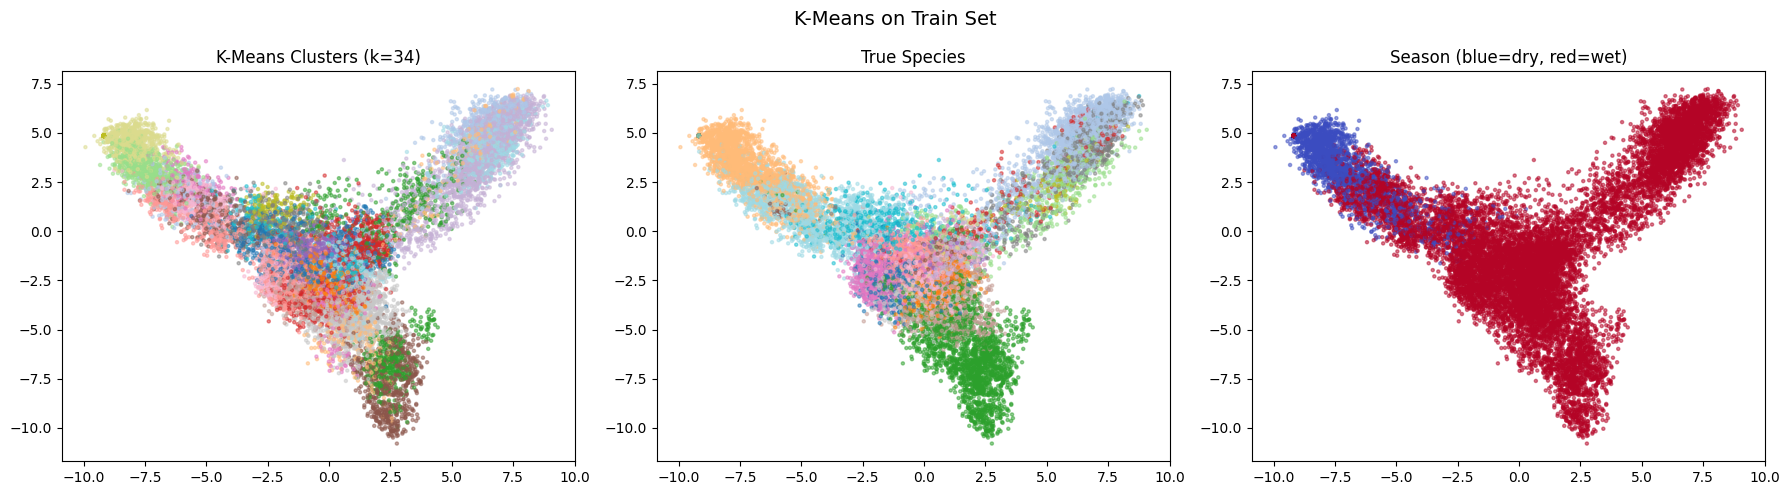

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ── 7. PCA plot ──────────────────────────────────────────────────
print("\nReducing to 2D for visualization...")
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_train)
print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('K-Means on Train Set', fontsize=14)

species_codes = pd.Categorical(meta_train['species']).codes

axes[0].scatter(X_2d[:,0], X_2d[:,1], c=meta_train['cluster'],
                cmap='tab20', s=5, alpha=0.5)
axes[0].set_title(f'K-Means Clusters (k={k})')

axes[1].scatter(X_2d[:,0], X_2d[:,1], c=species_codes,
                cmap='tab20', s=5, alpha=0.5)
axes[1].set_title('True Species')

axes[2].scatter(X_2d[:,0], X_2d[:,1], c=meta_train['is_wet_season'],
                cmap='coolwarm', s=5, alpha=0.5)
axes[2].set_title('Season (blue=dry, red=wet)')


plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/kmeans_train_purity.png', dpi=150)
plt.show()

Genus distribution:
genus
BOA    7384
LEP    2184
PHY    2084
SPH    1415
DEN     936
PIT     618
ADE     428
SCI     111
Name: count, dtype: int64


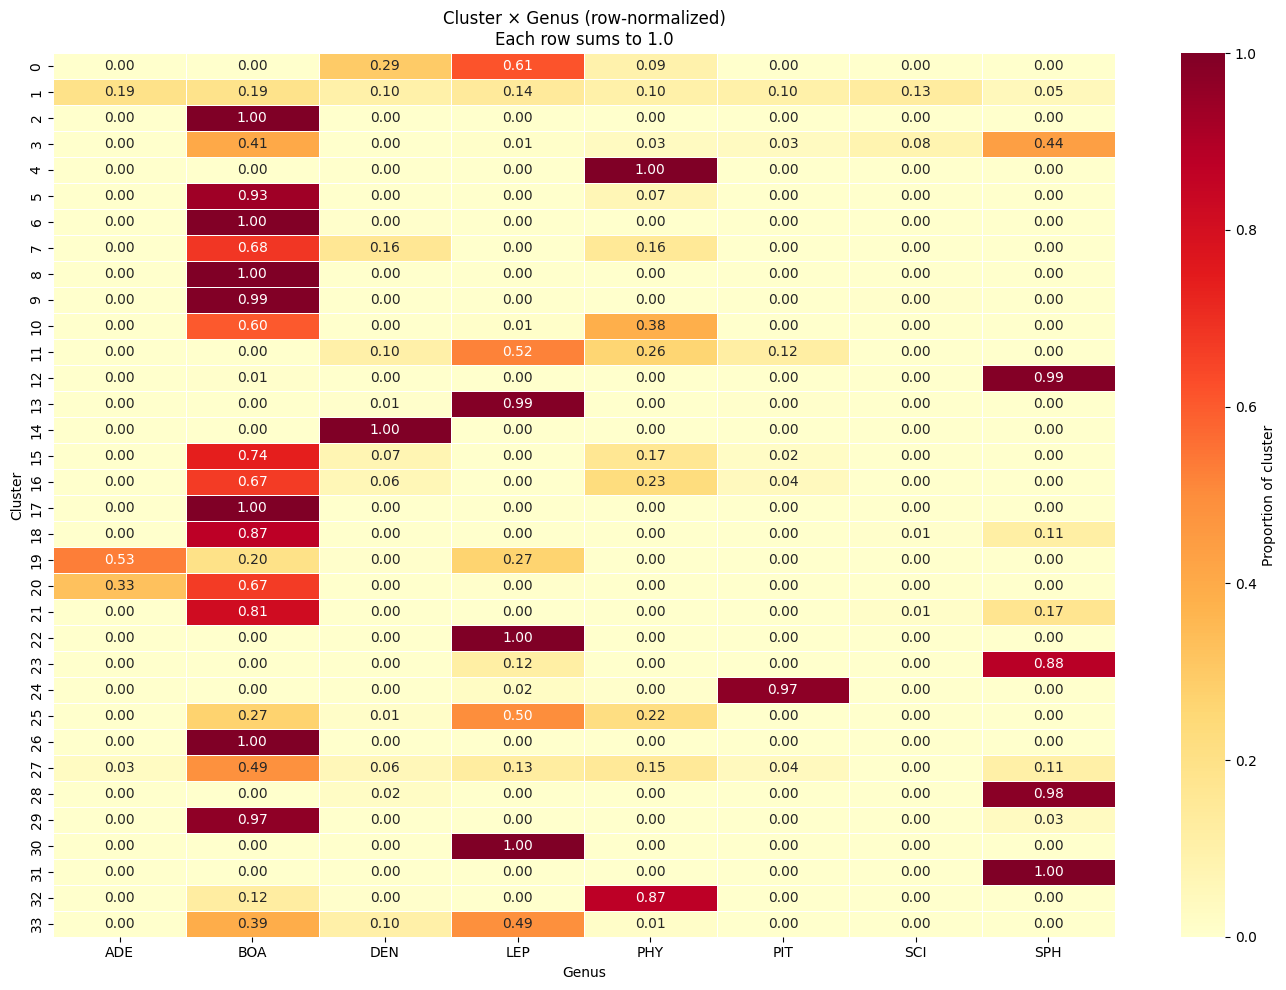


Clusters with >90% single genus: 17
Clusters with >75% single genus: 21
Clusters with <50% single genus: 5  ← these are the messy ones


In [ ]:
# Analysis attempt
import seaborn as sns
import matplotlib.pyplot as plt

# ── 1. Extract genus from species code ───────────────────────────
# e.g. BOABIS → BOA, SCIPER → SCI, PHYALB → PHY
meta_train['genus'] = meta_train['species'].str[:3]

print("Genus distribution:")
print(meta_train['genus'].value_counts())

# ── 2. Cluster × Genus confusion matrix ──────────────────────────
ct_genus = pd.crosstab(
    meta_train['cluster'],
    meta_train['genus'],
    normalize='index'
)

plt.figure(figsize=(14, 10))
sns.heatmap(
    ct_genus,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Proportion of cluster'}
)
plt.title('Cluster × Genus (row-normalized)\nEach row sums to 1.0')
plt.xlabel('Genus')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/cluster_genus_heatmap.png', dpi=150)
plt.show()

# ── 3. How many clusters are "pure genus" vs mixed ───────────────
ct_genus_raw = pd.crosstab(meta_train['cluster'], meta_train['genus'])
dominant_proportion = ct_genus.max(axis=1)

print(f"\nClusters with >90% single genus: {(dominant_proportion > 0.9).sum()}")
print(f"Clusters with >75% single genus: {(dominant_proportion > 0.75).sum()}")
print(f"Clusters with <50% single genus: {(dominant_proportion < 0.5).sum()}  ← these are the messy ones")

Clusters found: 34
Species in train: 22

── Dominant Species per Cluster ────────────────────────────
        dominant_species  dominant_count  total_count  hit_ratio
cluster                                                         
8                 BOAFAB             411          411   1.000000
2                 BOAALB             718          718   1.000000
26                BOAFAB             259          259   1.000000
30                LEPFUS             200          200   1.000000
17                BOAFAB             674          674   1.000000
22                LEPPOD             228          228   1.000000
31                SPHSUR             157          157   1.000000
14                DENMIN             504          505   0.998020
6                 BOAALB             205          206   0.995146
9                 BOABIS             668          672   0.994048
12                SPHSUR             487          491   0.991853
13                LEPPOD             479          484

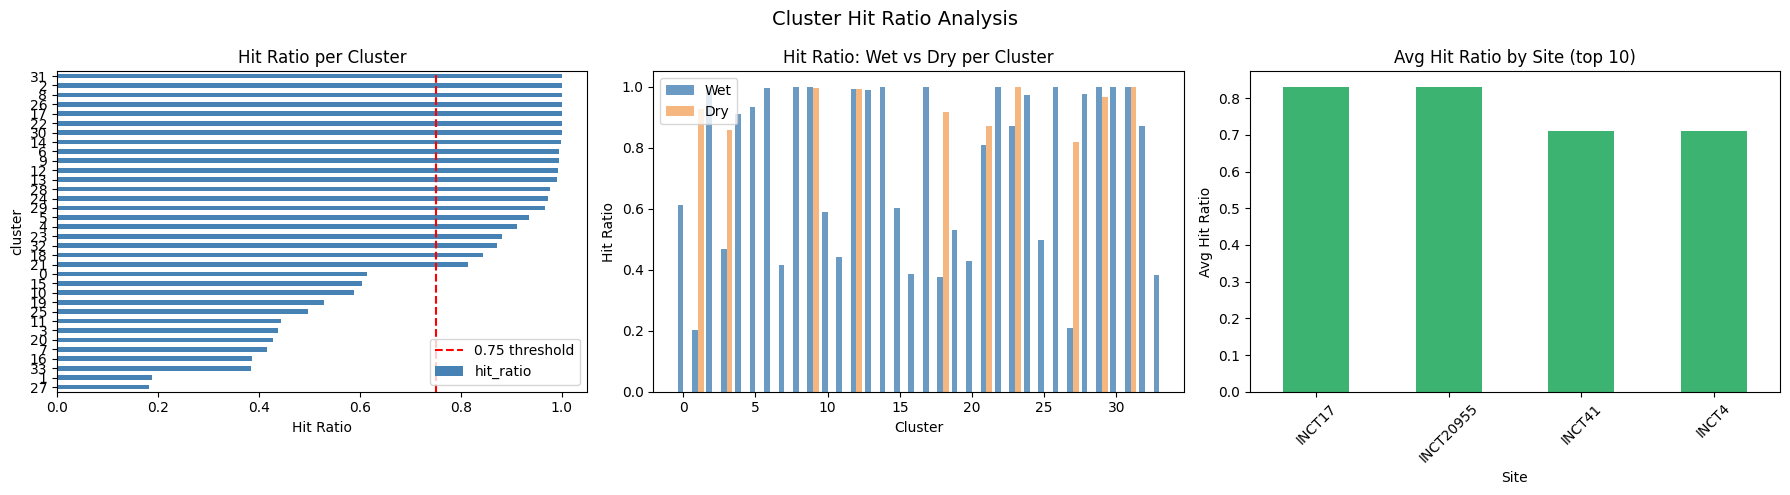

In [ ]:
# ── 1. Basic counts ──────────────────────────────────────────────
n_clusters = meta_train['cluster'].nunique()
n_species  = meta_train['species'].nunique()
print(f"Clusters found: {n_clusters}")
print(f"Species in train: {n_species}")

# ── 2. Dominant species per cluster + hit ratio ──────────────────
ct_raw = pd.crosstab(meta_train['cluster'], meta_train['species'])

cluster_summary = pd.DataFrame({
    'dominant_species': ct_raw.idxmax(axis=1),
    'dominant_count':   ct_raw.max(axis=1),
    'total_count':      ct_raw.sum(axis=1),
})
cluster_summary['hit_ratio'] = (
    cluster_summary['dominant_count'] / cluster_summary['total_count']
)
cluster_summary = cluster_summary.sort_values('hit_ratio', ascending=False)

print(f"\n── Dominant Species per Cluster ────────────────────────────")
print(cluster_summary.to_string())

# ── 3. Which species has the highest hit ratio overall ───────────
print(f"\n── Species with highest cluster dominance ──────────────────")
species_hit = cluster_summary.groupby('dominant_species')['hit_ratio'].max()
print(species_hit.sort_values(ascending=False).to_string())

# ── 4. Does season alter it? ─────────────────────────────────────
print(f"\n── Hit ratio by season ─────────────────────────────────────")
for season_val, season_name in [(1, 'Wet'), (0, 'Dry')]:
    mask = meta_train['is_wet_season'] == season_val
    ct_s = pd.crosstab(
        meta_train[mask]['cluster'],
        meta_train[mask]['species']
    )
    if ct_s.empty:
        continue
    hit = (ct_s.max(axis=1) / ct_s.sum(axis=1)).mean()
    print(f"  {season_name} season avg hit ratio: {hit:.4f}")

# ── 5. Does location alter it? ───────────────────────────────────
print(f"\n── Hit ratio by site (top 10 sites) ────────────────────────")
site_hits = []
for site in meta_train['site'].value_counts().head(10).index:
    mask = meta_train['site'] == site
    ct_s = pd.crosstab(
        meta_train[mask]['cluster'],
        meta_train[mask]['species']
    )
    if ct_s.empty:
        continue
    hit = (ct_s.max(axis=1) / ct_s.sum(axis=1)).mean()
    site_hits.append({'site': site, 'avg_hit_ratio': hit, 'n_samples': mask.sum()})

site_df = pd.DataFrame(site_hits).sort_values('avg_hit_ratio', ascending=False)
print(site_df.to_string(index=False))

# ── 6. Visual summary ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cluster Hit Ratio Analysis', fontsize=14)

# Hit ratio per cluster
cluster_summary['hit_ratio'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].axvline(0.75, color='red', linestyle='--', label='0.75 threshold')
axes[0].set_title('Hit Ratio per Cluster')
axes[0].set_xlabel('Hit Ratio')
axes[0].legend()

# Wet vs dry per cluster
wet_hits, dry_hits = [], []
for c in sorted(meta_train['cluster'].unique()):
    for season_val, store in [(1, wet_hits), (0, dry_hits)]:
        mask = (meta_train['cluster'] == c) & (meta_train['is_wet_season'] == season_val)
        sub = meta_train[mask]
        if len(sub) == 0:
            store.append(np.nan)
            continue
        ct_s = pd.crosstab(sub['cluster'], sub['species'])
        store.append((ct_s.max(axis=1) / ct_s.sum(axis=1)).mean())

x = np.arange(n_clusters)
axes[1].bar(x - 0.2, wet_hits, 0.4, label='Wet', color='steelblue', alpha=0.8)
axes[1].bar(x + 0.2, dry_hits, 0.4, label='Dry', color='sandybrown', alpha=0.8)
axes[1].set_title('Hit Ratio: Wet vs Dry per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Hit Ratio')
axes[1].legend()

# Site hit ratio
site_df.plot(kind='bar', x='site', y='avg_hit_ratio', ax=axes[2],
             color='mediumseagreen', legend=False)
axes[2].set_title('Avg Hit Ratio by Site (top 10)')
axes[2].set_xlabel('Site')
axes[2].set_ylabel('Avg Hit Ratio')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/hit_ratio_analysis.png', dpi=150)
plt.show()

BOAFAB total samples: 2053
BOAFAB clusters it appears in: 13
BOAFAB as dominant in N clusters: 4

Sample distribution across clusters:
cluster
1       7
5     228
8     411
10      7
12      2
17    674
18     11
19     87
20     52
25    197
26    259
27     30
33     88
Name: count, dtype: int64

Season breakdown:
is_wet_season
wet    2053
Name: count, dtype: int64

Site breakdown:
site
INCT4        2040
INCT20955      13
Name: count, dtype: int64

── Sample count vs cluster spread ──────────────────────────
species  n_samples  hit_ratio  n_clusters_spread
 BOAALB       2135   0.336300                  8
 BOAFAB       2053   0.328300                 13
 BOABIS       2010   0.351244                  9
 SPHSUR       1415   0.344170                 11
 LEPPOD        930   0.515054                 11
 PHYCUV        786   0.553435                  7
 BOALUN        680   0.438235                  6
 PHYALB        639   0.785603                  6
 PITAZU        618   0.663430              

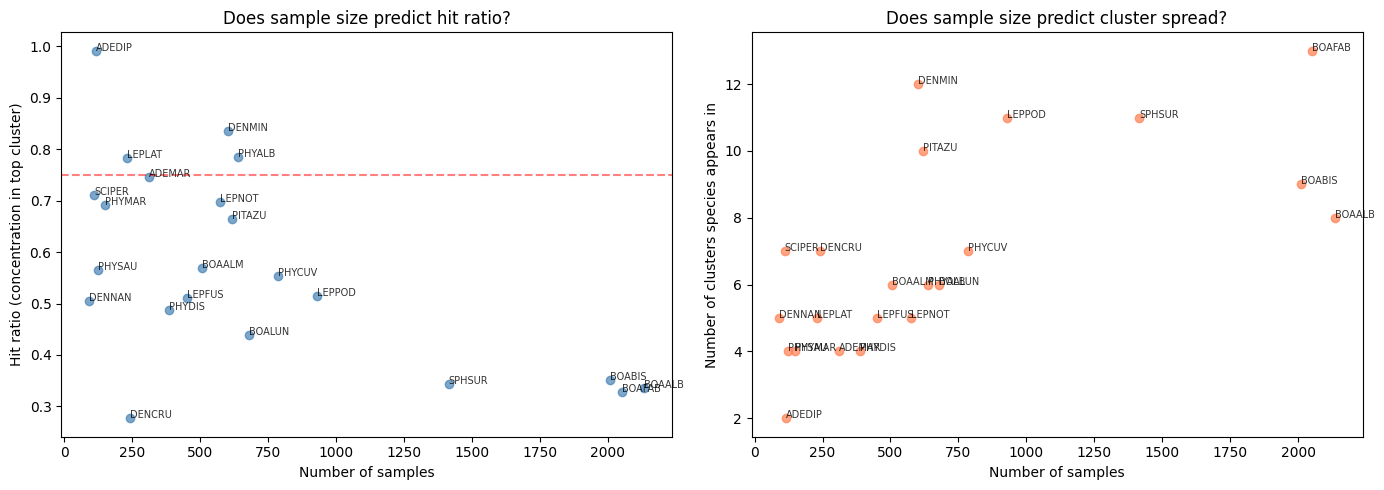


── Correlations ────────────────────────────────────────────
                   n_samples  n_clusters_spread  hit_ratio
n_samples              1.000              0.665     -0.594
n_clusters_spread      0.665              1.000     -0.408
hit_ratio             -0.594             -0.408      1.000


In [ ]:
# ── 1. BOAFAB deep dive ──────────────────────────────────────────
species = 'BOAFAB'
boafab = meta_train[meta_train['species'] == species].copy()

print(f"BOAFAB total samples: {len(boafab)}")
print(f"BOAFAB clusters it appears in: {boafab['cluster'].nunique()}")
print(f"BOAFAB as dominant in N clusters: {(cluster_summary['dominant_species'] == species).sum()}")

print(f"\nSample distribution across clusters:")
print(boafab['cluster'].value_counts().sort_index())

print(f"\nSeason breakdown:")
print(boafab['is_wet_season'].value_counts().rename({1:'wet', 0:'dry'}))

print(f"\nSite breakdown:")
print(boafab['site'].value_counts())

# ── 2. Is it sample size or acoustic diversity? ──────────────────
# Compare: for each species, plot sample count vs hit ratio
species_stats = []
for sp in meta_train['species'].unique():
    sp_mask = meta_train['species'] == sp
    n = sp_mask.sum()
    # which clusters does it appear in?
    sp_clusters = meta_train[sp_mask]['cluster'].value_counts()
    # hit ratio = proportion in its most common cluster
    hit = sp_clusters.iloc[0] / n
    n_clusters_in = len(sp_clusters)
    species_stats.append({
        'species': sp,
        'n_samples': n,
        'hit_ratio': hit,
        'n_clusters_spread': n_clusters_in
    })

stats_df = pd.DataFrame(species_stats).sort_values('n_samples', ascending=False)
print(f"\n── Sample count vs cluster spread ──────────────────────────")
print(stats_df.to_string(index=False))

# ── 3. Plot: sample size vs hit ratio ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatter: n_samples vs hit_ratio
axes[0].scatter(stats_df['n_samples'], stats_df['hit_ratio'], alpha=0.7, color='steelblue')
for _, row in stats_df.iterrows():
    axes[0].annotate(row['species'],
                     (row['n_samples'], row['hit_ratio']),
                     fontsize=7, alpha=0.8)
axes[0].axhline(0.75, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Number of samples')
axes[0].set_ylabel('Hit ratio (concentration in top cluster)')
axes[0].set_title('Does sample size predict hit ratio?')

# scatter: n_samples vs n_clusters_spread
axes[1].scatter(stats_df['n_samples'], stats_df['n_clusters_spread'], alpha=0.7, color='coral')
for _, row in stats_df.iterrows():
    axes[1].annotate(row['species'],
                     (row['n_samples'], row['n_clusters_spread']),
                     fontsize=7, alpha=0.8)
axes[1].set_xlabel('Number of samples')
axes[1].set_ylabel('Number of clusters species appears in')
axes[1].set_title('Does sample size predict cluster spread?')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/boafab_diagnosis.png', dpi=150)
plt.show()

# ── 4. Correlation: is spread driven by sample size? ─────────────
corr = stats_df[['n_samples', 'n_clusters_spread', 'hit_ratio']].corr()
print(f"\n── Correlations ────────────────────────────────────────────")
print(corr.round(3))

# k-means attempt 2
knowing how many species, and balacing by undersampling.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

TRAIN_SAMPLES_PER_SPECIES = 200
TEST_SAMPLES_PER_SPECIES = 50

species_counts_original = metadata_df['species'].value_counts()

required_total_samples = TRAIN_SAMPLES_PER_SPECIES + TEST_SAMPLES_PER_SPECIES
valid_species_for_new_sampling = species_counts_original[
    species_counts_original >= required_total_samples
].index

print(f"Original species count: {metadata_df['species'].nunique()}")
print(f"Species with at least {required_total_samples} samples: {len(valid_species_for_new_sampling)}")

mask_valid_species = metadata_df['species'].isin(valid_species_for_new_sampling)
metadata_filtered_new = metadata_df[mask_valid_species].reset_index(drop=True)
embeddings_filtered_new = embeddings[mask_valid_species]

print(f"Total samples after initial species filter: {len(metadata_filtered_new)}")

X_train_list, X_test_list = [], []
meta_train_list, meta_test_list = [], []

for species_name in valid_species_for_new_sampling:
    species_mask = metadata_filtered_new['species'] == species_name
    X_species = embeddings_filtered_new[species_mask]
    meta_species = metadata_filtered_new[species_mask].reset_index(drop=True)

    if len(meta_species) < required_total_samples:
        print(f"Skipping species '{species_name}': not enough samples ({len(meta_species)}) after initial filter.")
        continue

    indices = meta_species.index.tolist()
    train_samples_indices = np.random.choice(
        indices,
        size=TRAIN_SAMPLES_PER_SPECIES,
        replace=False
    )

    remaining_indices = [idx for idx in indices if idx not in train_samples_indices]

    test_samples_indices = np.random.choice(
        remaining_indices,
        size=TEST_SAMPLES_PER_SPECIES,
        replace=False
    )

    X_train_list.append(X_species[train_samples_indices])
    meta_train_list.append(meta_species.loc[train_samples_indices])

    X_test_list.append(X_species[test_samples_indices])
    meta_test_list.append(meta_species.loc[test_samples_indices])

X_train = np.vstack(X_train_list)
X_test = np.vstack(X_test_list)
meta_train = pd.concat(meta_train_list).reset_index(drop=True)
meta_test = pd.concat(meta_test_list).reset_index(drop=True)

print(f"\n--- New Sampling Results ---")
print(f"Train samples per species: {TRAIN_SAMPLES_PER_SPECIES}")
print(f"Test samples per species:  {TEST_SAMPLES_PER_SPECIES}")
print(f"Number of species included in new dataset: {meta_train['species'].nunique()}")
print(f"New X_train shape: {X_train.shape}")
print(f"New X_test shape:  {X_test.shape}")
print(f"New meta_train shape: {meta_train.shape}")
print(f"New meta_test shape:  {meta_test.shape}")

print(f"\nSpecies distribution in new train set:")
print(meta_train['species'].value_counts())
print(f"\nSpecies distribution in new test set:")
print(meta_test['species'].value_counts())

meta_train['genus'] = meta_train['species'].str[:3]
meta_test['genus'] = meta_test['species'].str[:3]

Original species count: 34
Species with at least 250 samples: 17
Total samples after initial species filter: 18212

--- New Sampling Results ---
Train samples per species: 200
Test samples per species:  50
Number of species included in new dataset: 17
New X_train shape: (3400, 1024)
New X_test shape:  (850, 1024)
New meta_train shape: (3400, 7)
New meta_test shape:  (850, 7)

Species distribution in new train set:
species
BOAALB    200
BOAFAB    200
BOABIS    200
SPHSUR    200
LEPPOD    200
PHYCUV    200
BOALUN    200
PHYALB    200
PITAZU    200
DENMIN    200
LEPNOT    200
BOAALM    200
LEPFUS    200
PHYDIS    200
ADEMAR    200
DENCRU    200
LEPLAT    200
Name: count, dtype: int64

Species distribution in new test set:
species
BOAALB    50
BOAFAB    50
BOABIS    50
SPHSUR    50
LEPPOD    50
PHYCUV    50
BOALUN    50
PHYALB    50
PITAZU    50
DENMIN    50
LEPNOT    50
BOAALM    50
LEPFUS    50
PHYDIS    50
ADEMAR    50
DENCRU    50
LEPLAT    50
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans

k = meta_train['species'].nunique()
print(f"\nFitting k-means with k={k} on train set...")

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
meta_train['cluster'] = kmeans.fit_predict(X_train)
print(f"Done! Inertia: {kmeans.inertia_:.2f}")


Fitting k-means with k=17 on train set...
Done! Inertia: 371623.89



── Cluster Purity (train) ──────────────────
  Adjusted Rand Index (ARI): 0.4638  (1.0 = perfect)
  Normalized Mutual Info:    0.6996  (1.0 = perfect)
  Purity Score:              0.6459  (1.0 = perfect)

Cluster × Species matrix (top 10 clusters):
species  ADEMAR  BOAALB  BOAALM  BOABIS  BOAFAB  BOALUN  DENCRU  DENMIN  \
cluster                                                                   
0             0      23       3       5       0      79     114       4   
1             0       0      45       0       9       0       1       7   
2             4       5       1       5       3       6       1       1   
3             0     103       0       0       0       0       2       0   
4             0       0       0       8       0       0       0       2   
5             0       0       0       0       0       0       0     180   
6             0      69       0       0       0     115      82       0   
7             0       0       0       0       0       0       0       0   


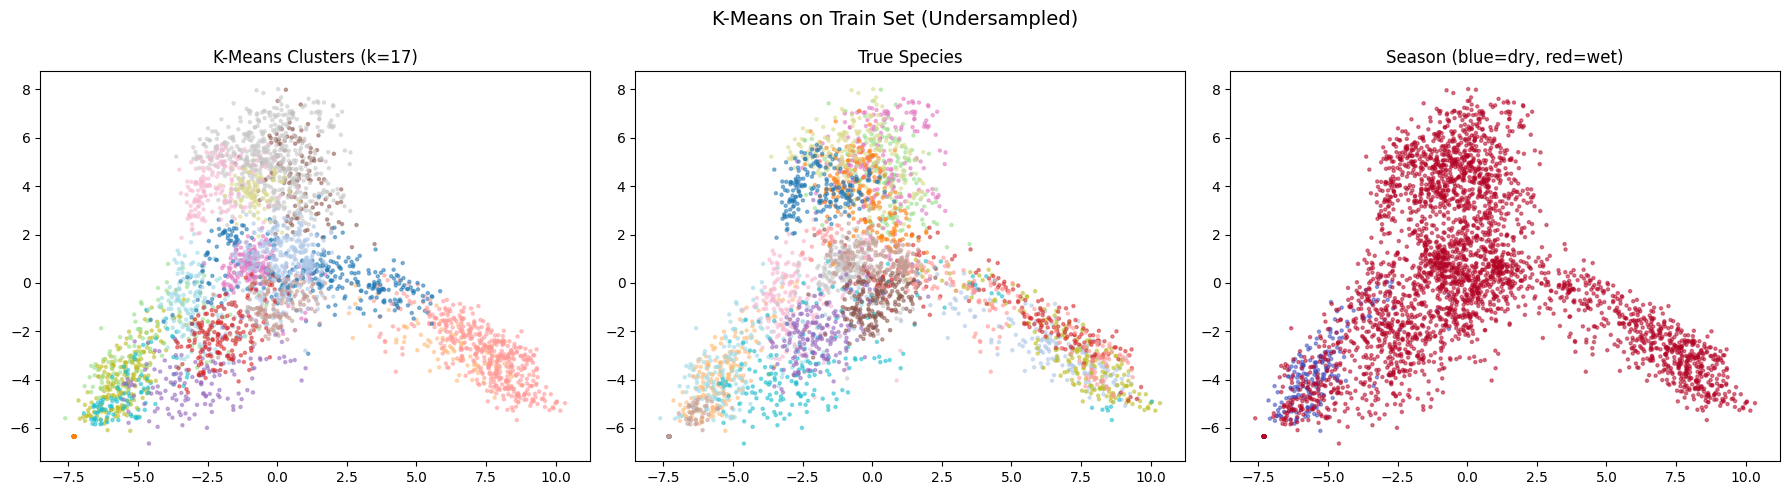


Genus distribution:
genus
BOA    1000
LEP     800
PHY     600
DEN     400
SPH     200
PIT     200
ADE     200
Name: count, dtype: int64


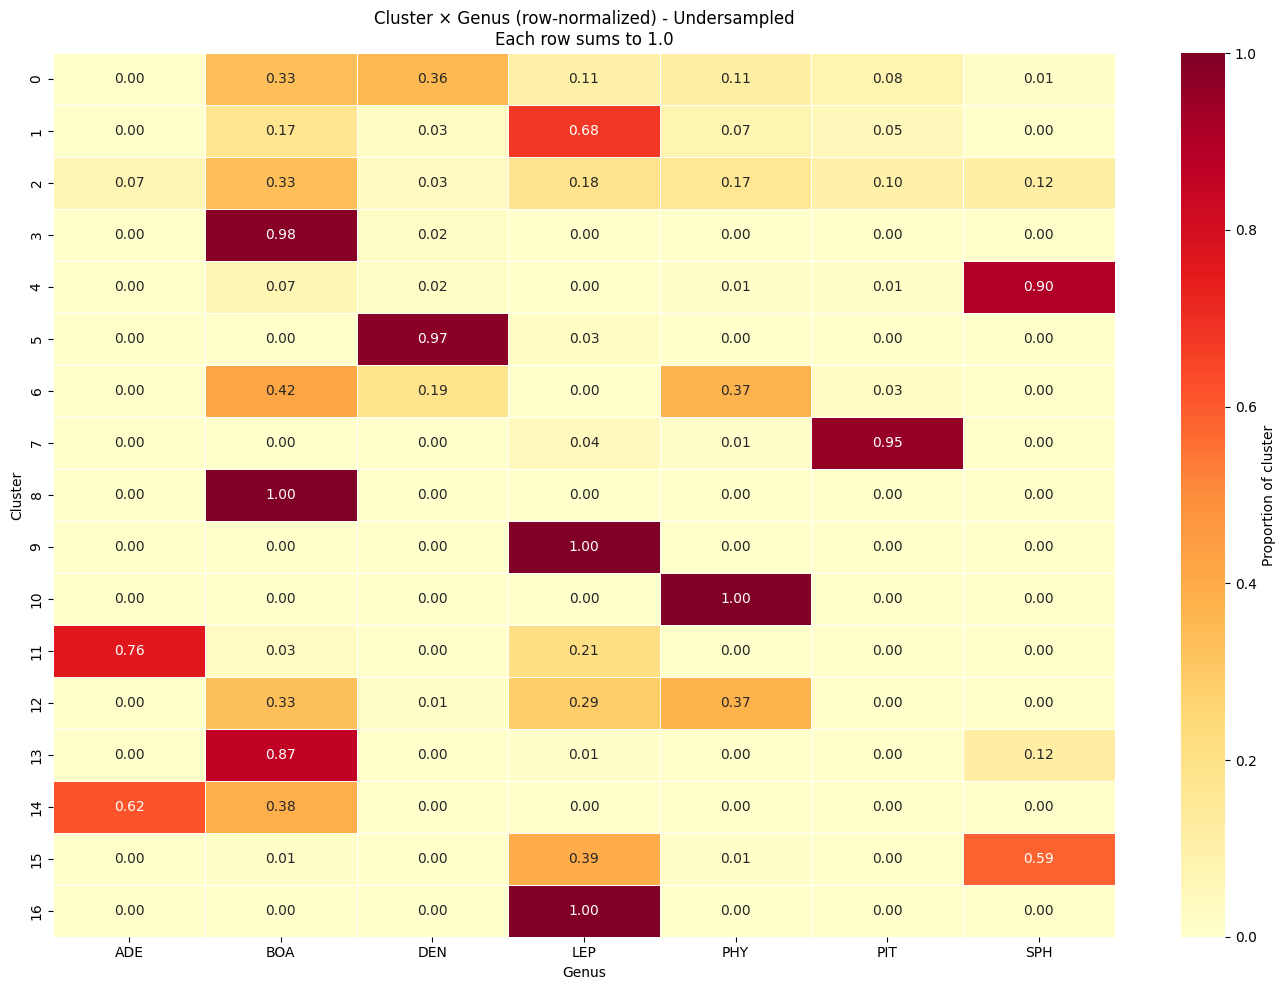


Clusters with >90% single genus: 7
Clusters with >75% single genus: 10
Clusters with <50% single genus: 4  ← these are the messy ones

Clusters found: 17
Species in train: 17

── Dominant Species per Cluster ────────────────────────────
        dominant_species  dominant_count  total_count  hit_ratio
cluster                                                         
8                 BOAFAB             126          126   1.000000
10                PHYALB             171          171   1.000000
16                LEPPOD             149          149   1.000000
9                 LEPFUS             154          154   1.000000
3                 BOAALB             103          105   0.980952
5                 DENMIN             180          185   0.972973
7                 PITAZU             140          147   0.952381
4                 SPHSUR             107          119   0.899160
13                BOABIS             181          210   0.861905
11                ADEMAR             138       

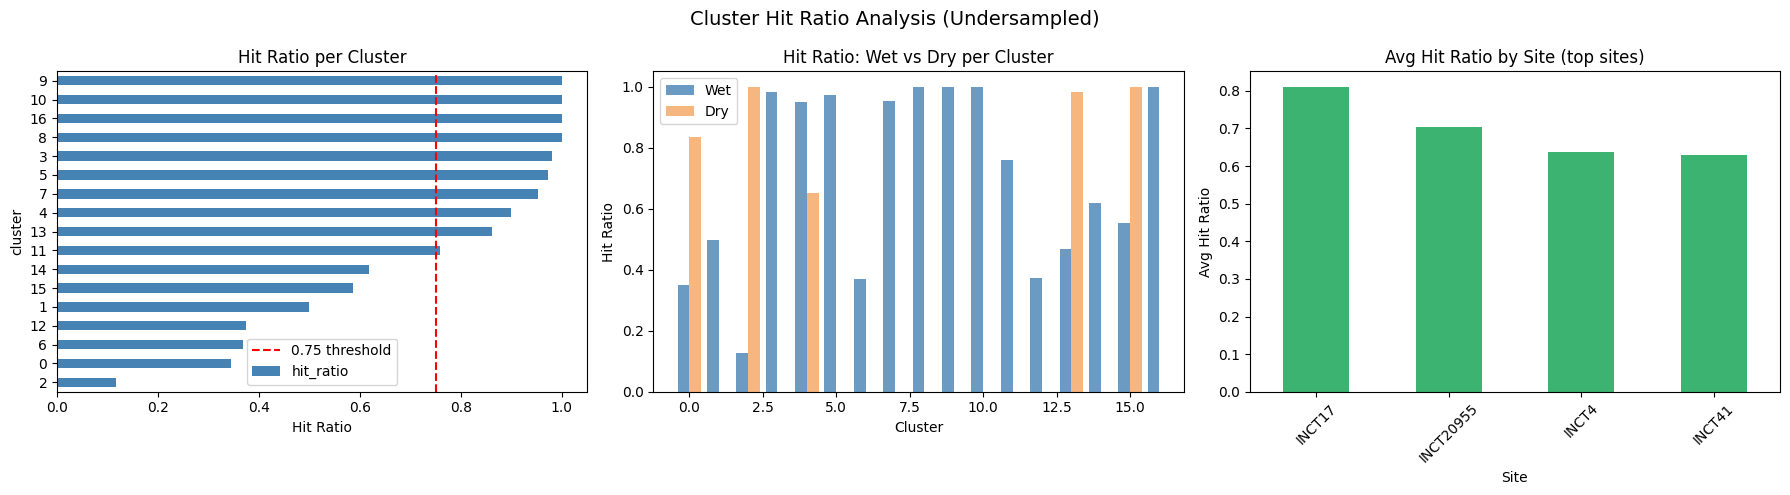


── BOAALB deep dive ──────────────────────────────────────────
BOAALB total samples: 200
BOAALB clusters it appears in: 4
BOAALB as dominant in N clusters: 1

Sample distribution across clusters:
cluster
0     23
2      5
3    103
6     69
Name: count, dtype: int64

Season breakdown:
is_wet_season
wet    200
Name: count, dtype: int64

Site breakdown:
site
INCT41    200
Name: count, dtype: int64

── Sample count vs cluster spread ──────────────────────────
species  n_samples  hit_ratio  n_clusters_spread
 BOAALB        200      0.515                  4
 BOAFAB        200      0.630                  7
 BOABIS        200      0.905                  5
 SPHSUR        200      0.535                  5
 LEPPOD        200      0.745                  6
 PHYCUV        200      0.810                  5
 BOALUN        200      0.575                  3
 PHYALB        200      0.855                  5
 PITAZU        200      0.700                  6
 DENMIN        200      0.900                  6


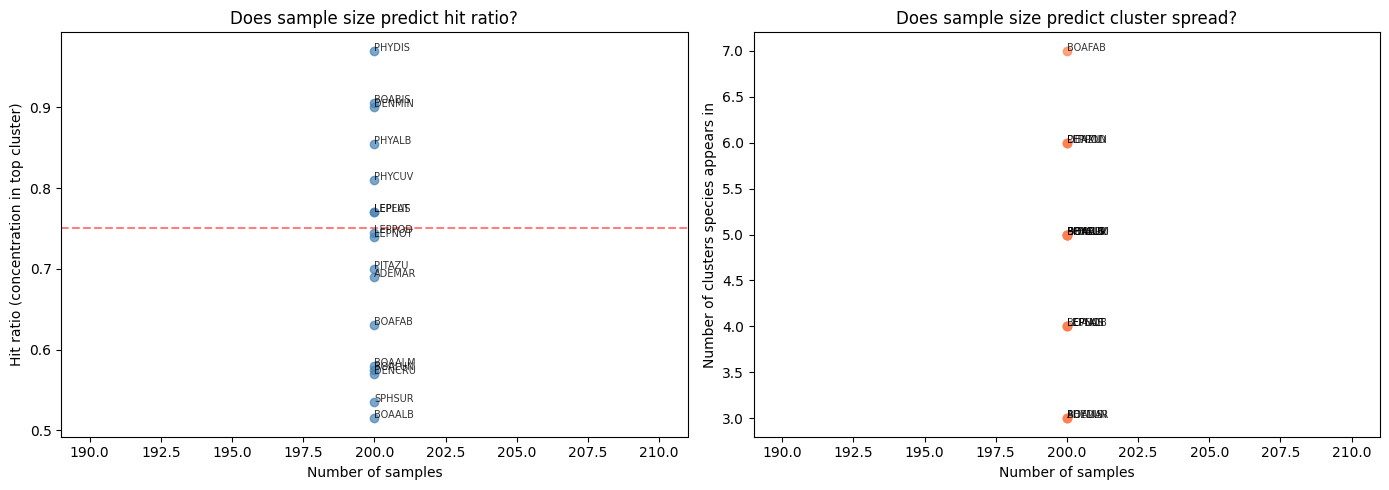


── Correlations ────────────────────────────────────────────
                   n_samples  n_clusters_spread  hit_ratio
n_samples                NaN                NaN        NaN
n_clusters_spread        NaN              1.000     -0.021
hit_ratio                NaN             -0.021      1.000


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cluster Purity Evaluation (ARI, NMI, Purity Score)
print(f"\n── Cluster Purity (train) ──────────────────")
true_labels = pd.Categorical(meta_train['species']).codes
ari  = adjusted_rand_score(true_labels, meta_train['cluster'])
nmi  = normalized_mutual_info_score(true_labels, meta_train['cluster'])

print(f"  Adjusted Rand Index (ARI): {ari:.4f}  (1.0 = perfect)")
print(f"  Normalized Mutual Info:    {nmi:.4f}  (1.0 = perfect)")

def purity_score(labels_true, labels_pred):
    ct = pd.crosstab(labels_pred, labels_true)
    return ct.max(axis=1).sum() / len(labels_true)

purity = purity_score(true_labels, meta_train['cluster'])
print(f"  Purity Score:              {purity:.4f}  (1.0 = perfect)")

# 2. Cluster × Species Matrix
ct = pd.crosstab(meta_train['cluster'], meta_train['species'])
print(f"\nCluster × Species matrix (top 10 clusters):")
print(ct.head(10))

# 3. PCA Plot
print("\nReducing to 2D for visualization...")
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_train)
k = meta_train['species'].nunique() # Re-fetch k for plot title if necessary
print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('K-Means on Train Set (Undersampled)', fontsize=14)

species_codes = pd.Categorical(meta_train['species']).codes

axes[0].scatter(X_2d[:,0], X_2d[:,1], c=meta_train['cluster'],
                cmap='tab20', s=5, alpha=0.5)
axes[0].set_title(f'K-Means Clusters (k={k})')

axes[1].scatter(X_2d[:,0], X_2d[:,1], c=species_codes,
                cmap='tab20', s=5, alpha=0.5)
axes[1].set_title('True Species')

axes[2].scatter(X_2d[:,0], X_2d[:,1], c=meta_train['is_wet_season'],
                cmap='coolwarm', s=5, alpha=0.5)
axes[2].set_title('Season (blue=dry, red=wet)')


plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/kmeans_train_purity_undersampled.png', dpi=150)
plt.show()

# 4. Cluster × Genus Heatmap and Purity Analysis
meta_train['genus'] = meta_train['species'].str[:3]

print("\nGenus distribution:")
print(meta_train['genus'].value_counts())

ct_genus = pd.crosstab(
    meta_train['cluster'],
    meta_train['genus'],
    normalize='index'
)

plt.figure(figsize=(14, 10))
sns.heatmap(
    ct_genus,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Proportion of cluster'}
)
plt.title('Cluster × Genus (row-normalized) - Undersampled\nEach row sums to 1.0')
plt.xlabel('Genus')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/cluster_genus_heatmap_undersampled.png', dpi=150)
plt.show()

ct_genus_raw = pd.crosstab(meta_train['cluster'], meta_train['genus'])
dominant_proportion = ct_genus.max(axis=1)

print(f"\nClusters with >90% single genus: {(dominant_proportion > 0.9).sum()}")
print(f"Clusters with >75% single genus: {(dominant_proportion > 0.75).sum()}")
print(f"Clusters with <50% single genus: {(dominant_proportion < 0.5).sum()}  ← these are the messy ones")

# 5. Dominant Species per Cluster and Hit Ratio Analysis
n_clusters = meta_train['cluster'].nunique()
n_species  = meta_train['species'].nunique()
print(f"\nClusters found: {n_clusters}")
print(f"Species in train: {n_species}")

ct_raw = pd.crosstab(meta_train['cluster'], meta_train['species'])

cluster_summary = pd.DataFrame({
    'dominant_species': ct_raw.idxmax(axis=1),
    'dominant_count':   ct_raw.max(axis=1),
    'total_count':      ct_raw.sum(axis=1),
})
cluster_summary['hit_ratio'] = (
    cluster_summary['dominant_count'] / cluster_summary['total_count']
)
cluster_summary = cluster_summary.sort_values('hit_ratio', ascending=False)

print(f"\n── Dominant Species per Cluster ────────────────────────────")
print(cluster_summary.to_string())

print(f"\n── Species with highest cluster dominance ──────────────────")
species_hit = cluster_summary.groupby('dominant_species')['hit_ratio'].max()
print(species_hit.sort_values(ascending=False).to_string())

print(f"\n── Hit ratio by season ─────────────────────────────────────")
for season_val, season_name in [(1, 'Wet'), (0, 'Dry')]:
    mask = meta_train['is_wet_season'] == season_val
    ct_s = pd.crosstab(
        meta_train[mask]['cluster'],
        meta_train[mask]['species']
    )
    if ct_s.empty:
        continue
    hit = (ct_s.max(axis=1) / ct_s.sum(axis=1)).mean()
    print(f"  {season_name} season avg hit ratio: {hit:.4f}")

print(f"\n── Hit ratio by site (top 10 sites) ────────────────────────")
site_hits = []
for site in meta_train['site'].value_counts().head(10).index:
    mask = meta_train['site'] == site
    ct_s = pd.crosstab(
        meta_train[mask]['cluster'],
        meta_train[mask]['species']
    )
    if ct_s.empty:
        continue
    hit = (ct_s.max(axis=1) / ct_s.sum(axis=1)).mean()
    site_hits.append({'site': site, 'avg_hit_ratio': hit, 'n_samples': mask.sum()})

site_df = pd.DataFrame(site_hits).sort_values('avg_hit_ratio', ascending=False)
print(site_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cluster Hit Ratio Analysis (Undersampled)', fontsize=14)

cluster_summary['hit_ratio'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].axvline(0.75, color='red', linestyle='--', label='0.75 threshold')
axes[0].set_title('Hit Ratio per Cluster')
axes[0].set_xlabel('Hit Ratio')
axes[0].legend()

wet_hits, dry_hits = [], []
for c in sorted(meta_train['cluster'].unique()):
    for season_val, store in [(1, wet_hits), (0, dry_hits)]:
        mask = (meta_train['cluster'] == c) & (meta_train['is_wet_season'] == season_val)
        sub = meta_train[mask]
        if len(sub) == 0:
            store.append(np.nan)
            continue
        ct_s = pd.crosstab(sub['cluster'], sub['species'])
        store.append((ct_s.max(axis=1) / ct_s.sum(axis=1)).mean())

x = np.arange(n_clusters)
axes[1].bar(x - 0.2, wet_hits, 0.4, label='Wet', color='steelblue', alpha=0.8)
axes[1].bar(x + 0.2, dry_hits, 0.4, label='Dry', color='sandybrown', alpha=0.8)
axes[1].set_title('Hit Ratio: Wet vs Dry per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Hit Ratio')
axes[1].legend()

site_df.plot(kind='bar', x='site', y='avg_hit_ratio', ax=axes[2],
             color='mediumseagreen', legend=False)
axes[2].set_title('Avg Hit Ratio by Site (top sites)')
axes[2].set_xlabel('Site')
axes[2].set_ylabel('Avg Hit Ratio')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/hit_ratio_analysis_undersampled.png', dpi=150)
plt.show()

# 6. Species-level Deep Dive and Correlation Analysis (using first species for example)
species = meta_train['species'].value_counts().index[0] # Pick the most frequent species, e.g. BOAALB
boafab = meta_train[meta_train['species'] == species].copy()

print(f"\n── {species} deep dive ──────────────────────────────────────────")
print(f"{species} total samples: {len(boafab)}")
print(f"{species} clusters it appears in: {boafab['cluster'].nunique()}")
print(f"{species} as dominant in N clusters: {(cluster_summary['dominant_species'] == species).sum()}")

print(f"\nSample distribution across clusters:")
print(boafab['cluster'].value_counts().sort_index())

print(f"\nSeason breakdown:")
print(boafab['is_wet_season'].value_counts().rename({1:'wet', 0:'dry'}))

print(f"\nSite breakdown:")
print(boafab['site'].value_counts())

species_stats = []
for sp in meta_train['species'].unique():
    sp_mask = meta_train['species'] == sp
    n = sp_mask.sum()
    sp_clusters = meta_train[sp_mask]['cluster'].value_counts()
    if len(sp_clusters) > 0:
      hit = sp_clusters.iloc[0] / n
    else:
      hit = 0.0 # No clusters found for this species
    n_clusters_in = len(sp_clusters)
    species_stats.append({
        'species': sp,
        'n_samples': n,
        'hit_ratio': hit,
        'n_clusters_spread': n_clusters_in
    })

stats_df = pd.DataFrame(species_stats).sort_values('n_samples', ascending=False)
print(f"\n── Sample count vs cluster spread ──────────────────────────")
print(stats_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(stats_df['n_samples'], stats_df['hit_ratio'], alpha=0.7, color='steelblue')
for _, row in stats_df.iterrows():
    axes[0].annotate(row['species'],
                     (row['n_samples'], row['hit_ratio']),
                     fontsize=7, alpha=0.8)
axes[0].axhline(0.75, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Number of samples')
axes[0].set_ylabel('Hit ratio (concentration in top cluster)')
axes[0].set_title('Does sample size predict hit ratio?')

axes[1].scatter(stats_df['n_samples'], stats_df['n_clusters_spread'], alpha=0.7, color='coral')
for _, row in stats_df.iterrows():
    axes[1].annotate(row['species'],
                     (row['n_samples'], row['n_clusters_spread']),
                     fontsize=7, alpha=0.8)
axes[1].set_xlabel('Number of samples')
axes[1].set_ylabel('Number of clusters species appears in')
axes[1].set_title('Does sample size predict cluster spread?')

plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/ribbit/{species}_diagnosis_undersampled.png', dpi=150)
plt.show()

corr = stats_df[['n_samples', 'n_clusters_spread', 'hit_ratio']].corr()
print(f"\n── Correlations ────────────────────────────────────────────")
print(corr.round(3))


Adjusted Rand Index (ARI) improved from 0.3484 to 0.4638.
Normalized Mutual Information (NMI) improved from 0.6575 to 0.6996.
However, the Purity Score slightly decreased from 0.7356 to 0.6459.
This indicates that while the clustering is generally better at capturing species-level relationships (higher ARI and NMI), the individual clusters are indeed less 'pure' with respect to containing a single dominant species.

# GMM clustering?
Elipsoids will it work?

In [ ]:
from sklearn.mixture import GaussianMixture

k = meta_train['species'].nunique()
print(f"\nFitting Gaussian Mixture Model with k={k} components on train set...")

gmm = GaussianMixture(n_components=k, random_state=42, n_init=10, covariance_type='full')
meta_train['gmm_cluster'] = gmm.fit_predict(X_train)
print(f"Done! Log-likelihood lower bound: {gmm.lower_bound_:.2f}")


Fitting Gaussian Mixture Model with k=17 components on train set...
Done! Log-likelihood lower bound: 4710.67


In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import pandas as pd

true_labels = pd.Categorical(meta_train['species']).codes
ari  = adjusted_rand_score(true_labels, meta_train['gmm_cluster'])
nmi  = normalized_mutual_info_score(true_labels, meta_train['gmm_cluster'])

print(f"\n── GMM Cluster Purity (train) ──────────────────")
print(f"  Adjusted Rand Index (ARI): {ari:.4f}  (1.0 = perfect)")
print(f"  Normalized Mutual Info:    {nmi:.4f}  (1.0 = perfect)")

def purity_score(labels_true, labels_pred):
    ct = pd.crosstab(labels_pred, labels_true)
    return ct.max(axis=1).sum() / len(labels_true)

purity = purity_score(true_labels, meta_train['gmm_cluster'])
print(f"  Purity Score:              {purity:.4f}  (1.0 = perfect)")


── GMM Cluster Purity (train) ──────────────────
  Adjusted Rand Index (ARI): 0.4666  (1.0 = perfect)
  Normalized Mutual Info:    0.6847  (1.0 = perfect)
  Purity Score:              0.6591  (1.0 = perfect)


In [ ]:
ct = pd.crosstab(meta_train['gmm_cluster'], meta_train['species'])
print(f"\nCluster × Species matrix (top 10 clusters for GMM):")
ct


Cluster × Species matrix (top 10 clusters for GMM):


species,ADEMAR,BOAALB,BOAALM,BOABIS,BOAFAB,BOALUN,DENCRU,DENMIN,LEPFUS,LEPLAT,LEPNOT,LEPPOD,PHYALB,PHYCUV,PHYDIS,PITAZU,SPHSUR
gmm_cluster,,,,,,,,,,,,,,,,,
0,58,0,78,0,8,0,0,1,0,81,0,0,3,0,0,0,3
1,0,29,0,0,0,17,21,0,0,0,0,0,0,140,0,1,0
2,130,0,0,0,3,0,0,0,0,0,1,0,0,0,0,0,1
3,0,0,0,1,0,0,0,1,0,39,0,0,0,2,0,0,157
4,0,0,69,0,28,0,0,5,0,0,48,0,0,0,124,0,0
5,0,0,0,0,0,0,0,0,0,0,0,153,0,0,0,0,0
6,0,0,0,0,0,0,0,180,0,0,0,5,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,166,0,0,0,0
8,0,0,0,0,0,0,0,0,98,0,0,0,0,0,0,0,0



Reducing to 2D for visualization...
Explained variance: 15.4%


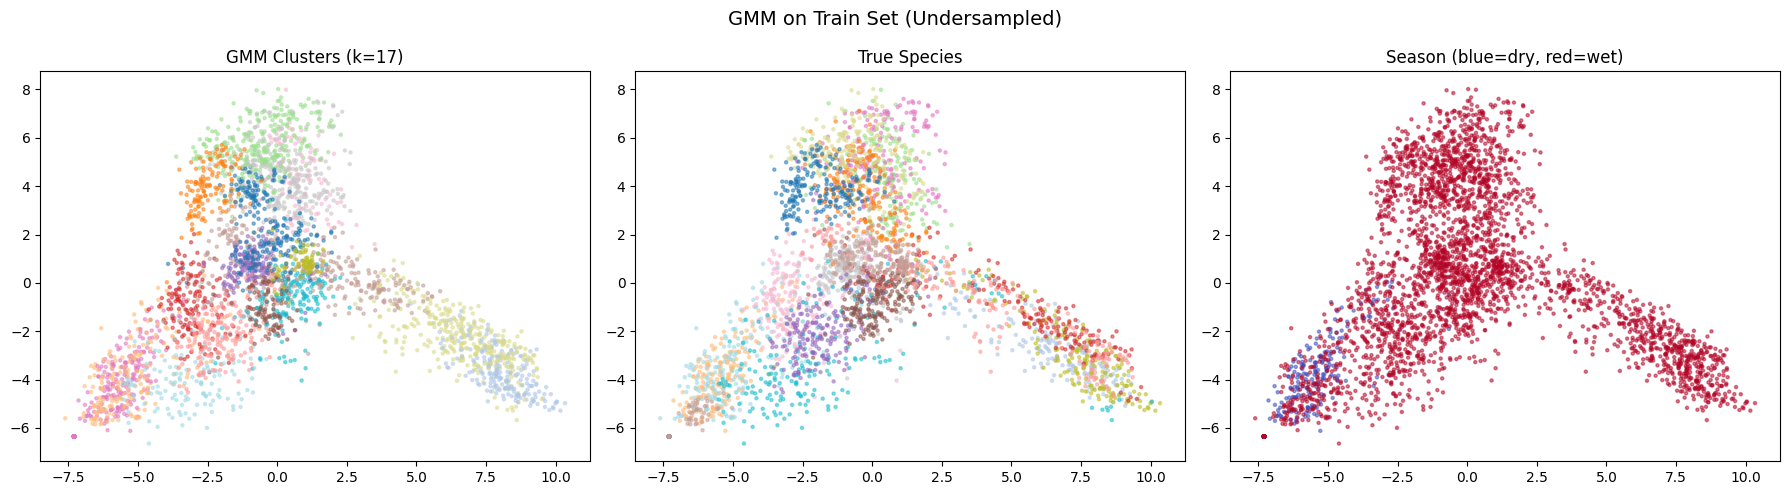

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ── PCA plot for GMM ──────────────────────────────────────────
print("\nReducing to 2D for visualization...")
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_train)
print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('GMM on Train Set (Undersampled)', fontsize=14)

species_codes = pd.Categorical(meta_train['species']).codes

axes[0].scatter(X_2d[:,0], X_2d[:,1], c=meta_train['gmm_cluster'],
                cmap='tab20', s=5, alpha=0.5)
axes[0].set_title(f'GMM Clusters (k={k})')

axes[1].scatter(X_2d[:,0], X_2d[:,1], c=species_codes,
                cmap='tab20', s=5, alpha=0.5)
axes[1].set_title('True Species')

axes[2].scatter(X_2d[:,0], X_2d[:,1], c=meta_train['is_wet_season'],
                cmap='coolwarm', s=5, alpha=0.5)
axes[2].set_title('Season (blue=dry, red=wet)')


plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/gmm_train_purity_undersampled.png', dpi=150)
plt.show()


Genus distribution (GMM):
genus
BOA    1000
LEP     800
PHY     600
DEN     400
SPH     200
PIT     200
ADE     200
Name: count, dtype: int64


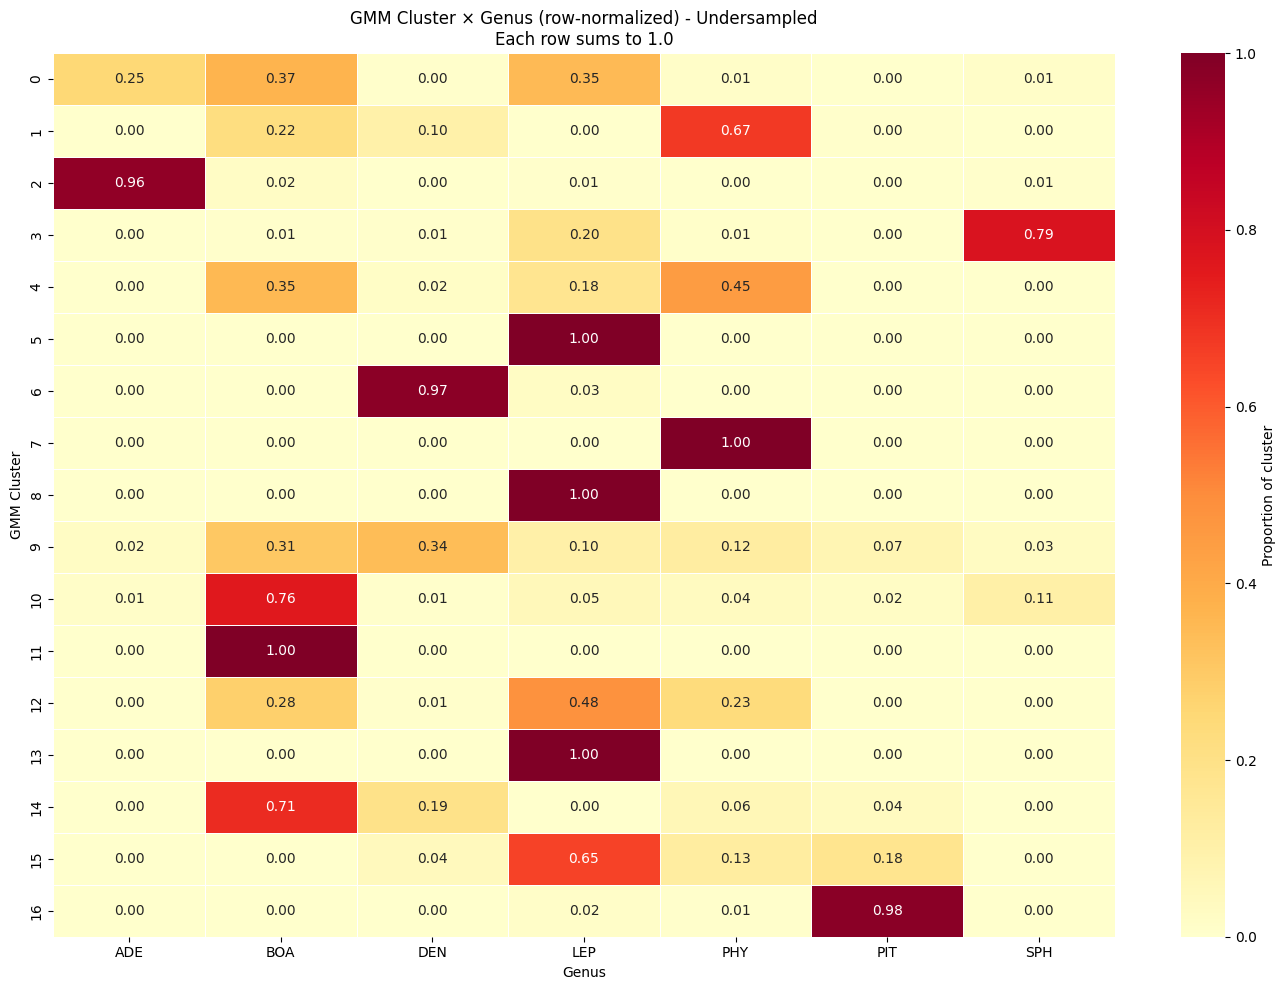


Clusters with >90% single genus (GMM): 8
Clusters with >75% single genus (GMM): 10
Clusters with <50% single genus (GMM): 4  ← these are the messy ones


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ── Cluster × Genus Heatmap and Purity Analysis for GMM ───────────────────────────
# Ensure 'genus' column exists, though it should from previous K-Means analysis
if 'genus' not in meta_train.columns:
    meta_train['genus'] = meta_train['species'].str[:3]

print("\nGenus distribution (GMM):")
print(meta_train['genus'].value_counts())

ct_genus = pd.crosstab(
    meta_train['gmm_cluster'],
    meta_train['genus'],
    normalize='index'
)

plt.figure(figsize=(14, 10))
sns.heatmap(
    ct_genus,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Proportion of cluster'}
)
plt.title('GMM Cluster × Genus (row-normalized) - Undersampled\nEach row sums to 1.0')
plt.xlabel('Genus')
plt.ylabel('GMM Cluster')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/gmm_cluster_genus_heatmap_undersampled.png', dpi=150)
plt.show()

ct_genus_raw = pd.crosstab(meta_train['gmm_cluster'], meta_train['genus'])
dominant_proportion = ct_genus.max(axis=1)

print(f"\nClusters with >90% single genus (GMM): {(dominant_proportion > 0.9).sum()}")
print(f"Clusters with >75% single genus (GMM): {(dominant_proportion > 0.75).sum()}")
print(f"Clusters with <50% single genus (GMM): {(dominant_proportion < 0.5).sum()}  ← these are the messy ones")


Clusters found (GMM): 17
Species in train: 17

── Dominant Species per GMM Cluster ────────────────────────────
            dominant_species  dominant_count  total_count  hit_ratio
gmm_cluster                                                         
7                     PHYALB             166          166   1.000000
13                    LEPLAT              73           73   1.000000
8                     LEPFUS              98           98   1.000000
5                     LEPPOD             153          153   1.000000
11                    BOAFAB             121          121   1.000000
16                    PITAZU             128          131   0.977099
6                     DENMIN             180          185   0.972973
2                     ADEMAR             130          135   0.962963
3                     SPHSUR             157          200   0.785000
10                    BOABIS             191          272   0.702206
1                     PHYCUV             140          208  

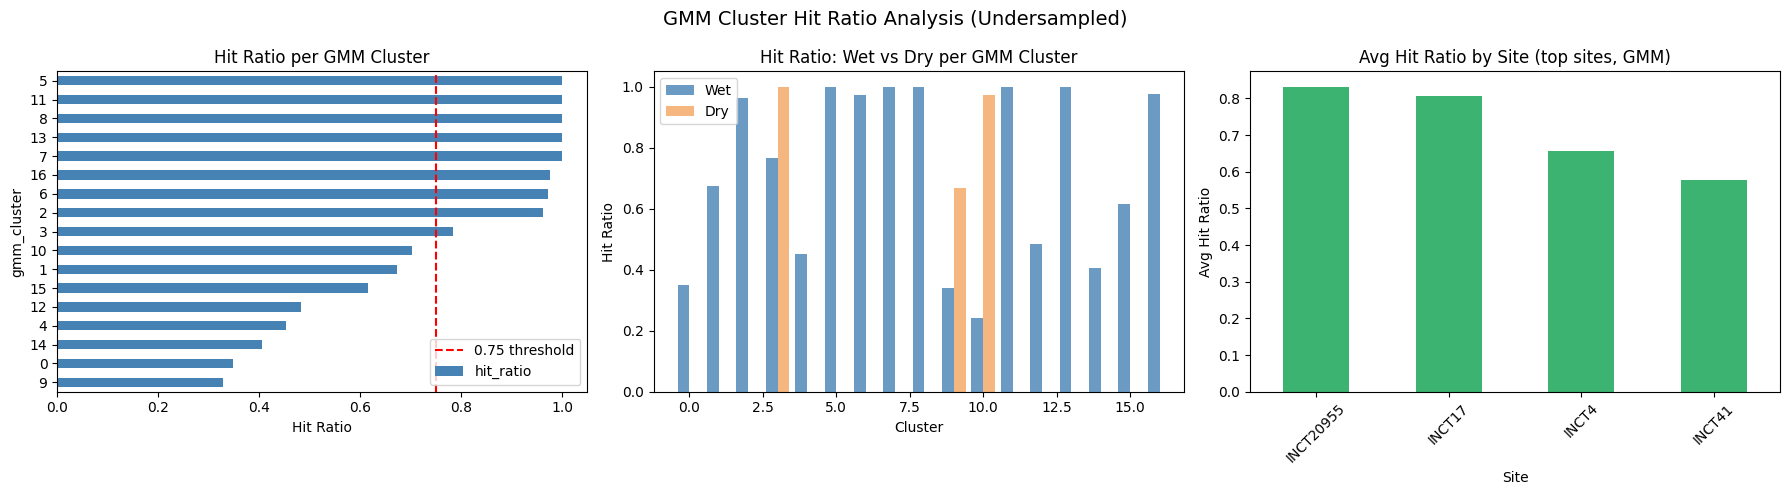

In [ ]:
# ── Dominant Species per Cluster and Hit Ratio Analysis for GMM ───────────────────
n_clusters_gmm = meta_train['gmm_cluster'].nunique()
n_species  = meta_train['species'].nunique()
print(f"\nClusters found (GMM): {n_clusters_gmm}")
print(f"Species in train: {n_species}")

ct_raw_gmm = pd.crosstab(meta_train['gmm_cluster'], meta_train['species'])

cluster_summary_gmm = pd.DataFrame({
    'dominant_species': ct_raw_gmm.idxmax(axis=1),
    'dominant_count':   ct_raw_gmm.max(axis=1),
    'total_count':      ct_raw_gmm.sum(axis=1),
})
cluster_summary_gmm['hit_ratio'] = (
    cluster_summary_gmm['dominant_count'] / cluster_summary_gmm['total_count']
)
cluster_summary_gmm = cluster_summary_gmm.sort_values('hit_ratio', ascending=False)

print(f"\n── Dominant Species per GMM Cluster ────────────────────────────")
print(cluster_summary_gmm.to_string())

print(f"\n── Species with highest GMM cluster dominance ──────────────────")
species_hit_gmm = cluster_summary_gmm.groupby('dominant_species')['hit_ratio'].max()
print(species_hit_gmm.sort_values(ascending=False).to_string())

print(f"\n── Hit ratio by season (GMM) ─────────────────────────────────────")
for season_val, season_name in [(1, 'Wet'), (0, 'Dry')]:
    mask = meta_train['is_wet_season'] == season_val
    ct_s = pd.crosstab(
        meta_train[mask]['gmm_cluster'],
        meta_train[mask]['species']
    )
    if ct_s.empty:
        continue
    hit = (ct_s.max(axis=1) / ct_s.sum(axis=1)).mean()
    print(f"  {season_name} season avg hit ratio: {hit:.4f}")

print(f"\n── Hit ratio by site (top 10 sites, GMM) ────────────────────────")
site_hits_gmm = []
for site in meta_train['site'].value_counts().head(10).index:
    mask = meta_train['site'] == site
    ct_s = pd.crosstab(
        meta_train[mask]['gmm_cluster'],
        meta_train[mask]['species']
    )
    if ct_s.empty:
        continue
    hit = (ct_s.max(axis=1) / ct_s.sum(axis=1)).mean()
    site_hits_gmm.append({'site': site, 'avg_hit_ratio': hit, 'n_samples': mask.sum()})

site_df_gmm = pd.DataFrame(site_hits_gmm).sort_values('avg_hit_ratio', ascending=False)
print(site_df_gmm.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('GMM Cluster Hit Ratio Analysis (Undersampled)', fontsize=14)

cluster_summary_gmm['hit_ratio'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].axvline(0.75, color='red', linestyle='--', label='0.75 threshold')
axes[0].set_title('Hit Ratio per GMM Cluster')
axes[0].set_xlabel('Hit Ratio')
axes[0].legend()

wet_hits, dry_hits = [], []
for c in sorted(meta_train['gmm_cluster'].unique()):
    for season_val, store in [(1, wet_hits), (0, dry_hits)]:
        mask = (meta_train['gmm_cluster'] == c) & (meta_train['is_wet_season'] == season_val)
        sub = meta_train[mask]
        if len(sub) == 0:
            store.append(np.nan)
            continue
        ct_s = pd.crosstab(sub['gmm_cluster'], sub['species'])
        store.append((ct_s.max(axis=1) / ct_s.sum(axis=1)).mean())

x = np.arange(n_clusters_gmm)
axes[1].bar(x - 0.2, wet_hits, 0.4, label='Wet', color='steelblue', alpha=0.8)
axes[1].bar(x + 0.2, dry_hits, 0.4, label='Dry', color='sandybrown', alpha=0.8)
axes[1].set_title('Hit Ratio: Wet vs Dry per GMM Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Hit Ratio')
axes[1].legend()

site_df_gmm.plot(kind='bar', x='site', y='avg_hit_ratio', ax=axes[2],
             color='mediumseagreen', legend=False)
axes[2].set_title('Avg Hit Ratio by Site (top sites, GMM)')
axes[2].set_xlabel('Site')
axes[2].set_ylabel('Avg Hit Ratio')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/gmm_hit_ratio_analysis_undersampled.png', dpi=150)
plt.show()


── BOAALB deep dive (GMM) ──────────────────────────────────────────
BOAALB total samples: 200
BOAALB clusters it appears in (GMM): 4
BOAALB as dominant in N clusters (GMM): 1

Sample distribution across GMM clusters:
gmm_cluster
1      29
9      22
10      5
14    144
Name: count, dtype: int64

Season breakdown (GMM):
is_wet_season
wet    200
Name: count, dtype: int64

Site breakdown (GMM):
site
INCT41    200
Name: count, dtype: int64

── Sample count vs cluster spread (GMM) ──────────────────────────
species  n_samples  hit_ratio  n_clusters_spread
 BOAALB        200      0.720                  4
 BOAFAB        200      0.605                  6
 BOABIS        200      0.955                  3
 SPHSUR        200      0.785                  5
 LEPPOD        200      0.765                  6
 PHYCUV        200      0.700                  5
 BOALUN        200      0.540                  4
 PHYALB        200      0.830                  6
 PITAZU        200      0.640                  6
 

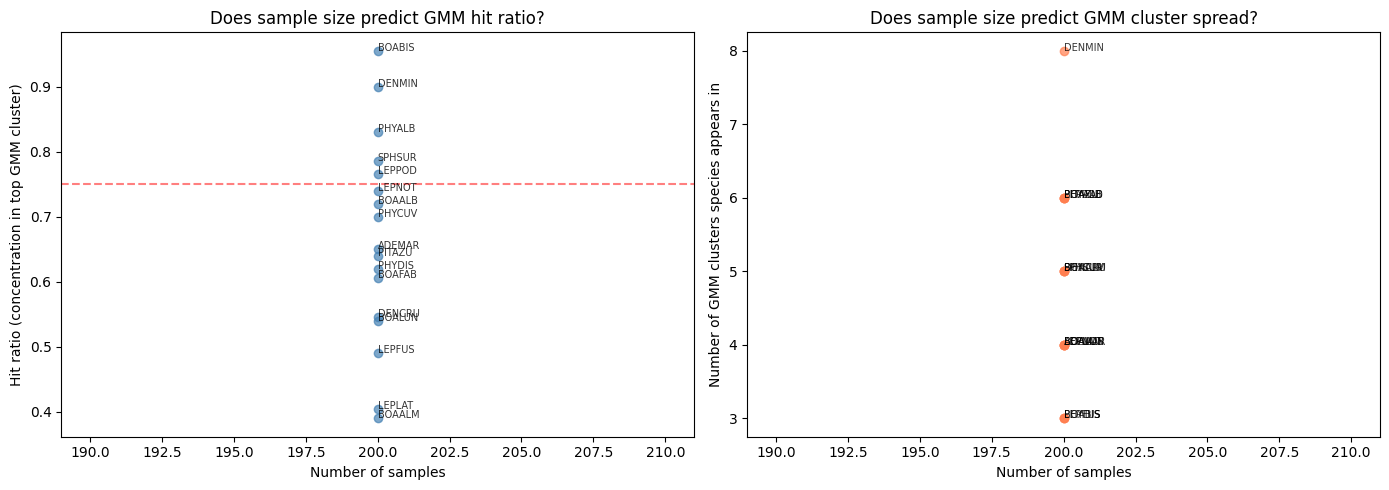


── Correlations (GMM) ────────────────────────────────────────────
                   n_samples  n_clusters_spread  hit_ratio
n_samples                NaN                NaN        NaN
n_clusters_spread        NaN              1.000      0.292
hit_ratio                NaN              0.292      1.000


In [ ]:
# ── Species-level Deep Dive and Correlation Analysis (GMM) ──────────────────────────
species_to_analyze = meta_train['species'].value_counts().index[0]

boafab_gmm = meta_train[meta_train['species'] == species_to_analyze].copy()

print(f"\n── {species_to_analyze} deep dive (GMM) ──────────────────────────────────────────")
print(f"{species_to_analyze} total samples: {len(boafab_gmm)}")
print(f"{species_to_analyze} clusters it appears in (GMM): {boafab_gmm['gmm_cluster'].nunique()}")
print(f"{species_to_analyze} as dominant in N clusters (GMM): {(cluster_summary_gmm['dominant_species'] == species_to_analyze).sum()}")

print(f"\nSample distribution across GMM clusters:")
print(boafab_gmm['gmm_cluster'].value_counts().sort_index())

print(f"\nSeason breakdown (GMM):")
print(boafab_gmm['is_wet_season'].value_counts().rename({1:'wet', 0:'dry'}))

print(f"\nSite breakdown (GMM):")
print(boafab_gmm['site'].value_counts())

species_stats_gmm = []
for sp in meta_train['species'].unique():
    sp_mask = meta_train['species'] == sp
    n = sp_mask.sum()
    sp_clusters = meta_train[sp_mask]['gmm_cluster'].value_counts()
    if len(sp_clusters) > 0:
      hit = sp_clusters.iloc[0] / n
    else:
      hit = 0.0 # No clusters found for this species
    n_clusters_in = len(sp_clusters)
    species_stats_gmm.append({
        'species': sp,
        'n_samples': n,
        'hit_ratio': hit,
        'n_clusters_spread': n_clusters_in
    })

stats_df_gmm = pd.DataFrame(species_stats_gmm).sort_values('n_samples', ascending=False)
print(f"\n── Sample count vs cluster spread (GMM) ──────────────────────────")
print(stats_df_gmm.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(stats_df_gmm['n_samples'], stats_df_gmm['hit_ratio'], alpha=0.7, color='steelblue')
for _, row in stats_df_gmm.iterrows():
    axes[0].annotate(row['species'],
                     (row['n_samples'], row['hit_ratio']),
                     fontsize=7, alpha=0.8)
axes[0].axhline(0.75, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Number of samples')
axes[0].set_ylabel('Hit ratio (concentration in top GMM cluster)')
axes[0].set_title('Does sample size predict GMM hit ratio?')

axes[1].scatter(stats_df_gmm['n_samples'], stats_df_gmm['n_clusters_spread'], alpha=0.7, color='coral')
for _, row in stats_df_gmm.iterrows():
    axes[1].annotate(row['species'],
                     (row['n_samples'], row['n_clusters_spread']),
                     fontsize=7, alpha=0.8)
axes[1].set_xlabel('Number of samples')
axes[1].set_ylabel('Number of GMM clusters species appears in')
axes[1].set_title('Does sample size predict GMM cluster spread?')

plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/ribbit/{species_to_analyze}_gmm_diagnosis_undersampled.png', dpi=150)
plt.show()

corr_gmm = stats_df_gmm[['n_samples', 'n_clusters_spread', 'hit_ratio']].corr()
print(f"\n── Correlations (GMM) ────────────────────────────────────────────")
print(corr_gmm.round(3))

In [ ]:
# PCA + Kmeans?
Maybe reducing dimensionality?

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

n_components =100 # Let's reduce the 1024 dimensions to 50
print(f"\nPerforming PCA to reduce dimensionality to {n_components} components...")
pca_model = PCA(n_components=n_components, random_state=42)
X_train_pca = pca_model.fit_transform(X_train)
print(f"Explained variance with {n_components} components: {pca_model.explained_variance_ratio_.sum()*100:.1f}%")

k = meta_train['species'].nunique()
print(f"\nFitting K-Means with k={k} on PCA-transformed train set (n_components={n_components})...")

kmeans_pca = KMeans(n_clusters=k, random_state=42, n_init=10)
meta_train['kmeans_pca_cluster'] = kmeans_pca.fit_predict(X_train_pca)
print(f"Done! Inertia: {kmeans_pca.inertia_:.2f}")


Performing PCA to reduce dimensionality to 100 components...
Explained variance with 100 components: 80.6%

Fitting K-Means with k=17 on PCA-transformed train set (n_components=100)...
Done! Inertia: 253640.24


In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt

# Evaluate K-Means on PCA-transformed data
true_labels = pd.Categorical(meta_train['species']).codes
ari_pca  = adjusted_rand_score(true_labels, meta_train['kmeans_pca_cluster'])
nmi_pca  = normalized_mutual_info_score(true_labels, meta_train['kmeans_pca_cluster'])

print(f"\n── PCA + K-Means Cluster Purity (train) ──────────────────")
print(f"  Adjusted Rand Index (ARI): {ari_pca:.4f}  (1.0 = perfect)")
print(f"  Normalized Mutual Info:    {nmi_pca:.4f}  (1.0 = perfect)")

def purity_score(labels_true, labels_pred):
    ct = pd.crosstab(labels_pred, labels_true)
    return ct.max(axis=1).sum() / len(labels_true)

purity_pca = purity_score(true_labels, meta_train['kmeans_pca_cluster'])
print(f"  Purity Score:              {purity_pca:.4f}  (1.0 = perfect)")


── PCA + K-Means Cluster Purity (train) ──────────────────
  Adjusted Rand Index (ARI): 0.5042  (1.0 = perfect)
  Normalized Mutual Info:    0.7077  (1.0 = perfect)
  Purity Score:              0.6853  (1.0 = perfect)



Explained variance for 2D visualization: 19.1%


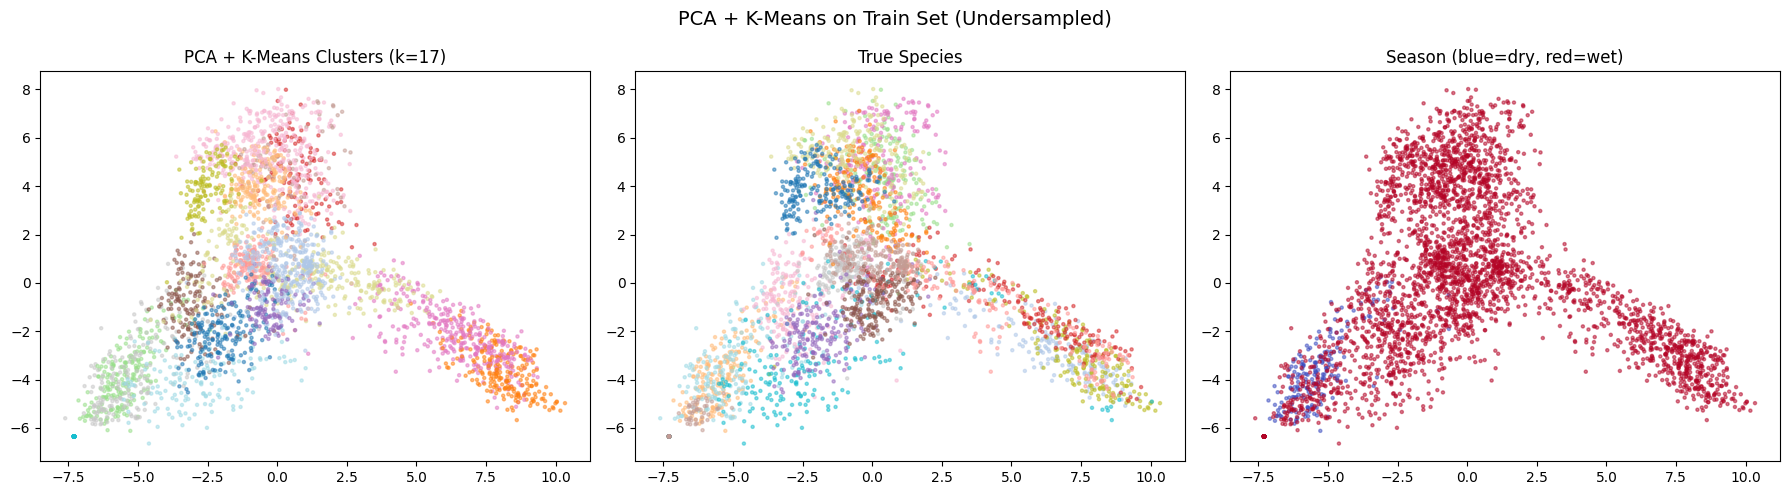

In [ ]:
# Visualize PCA + K-Means results

# Reduce X_train_pca to 2 dimensions for visualization only
pca_viz = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_viz.fit_transform(X_train_pca)
print(f"\nExplained variance for 2D visualization: {pca_viz.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PCA + K-Means on Train Set (Undersampled)', fontsize=14)

species_codes = pd.Categorical(meta_train['species']).codes
k_pca = meta_train['species'].nunique() # Number of clusters for K-Means

axes[0].scatter(X_train_pca_2d[:,0], X_train_pca_2d[:,1], c=meta_train['kmeans_pca_cluster'],
                cmap='tab20', s=5, alpha=0.5)
axes[0].set_title(f'PCA + K-Means Clusters (k={k_pca})')

axes[1].scatter(X_train_pca_2d[:,0], X_train_pca_2d[:,1], c=species_codes,
                cmap='tab20', s=5, alpha=0.5)
axes[1].set_title('True Species')

axes[2].scatter(X_train_pca_2d[:,0], X_train_pca_2d[:,1], c=meta_train['is_wet_season'],
                cmap='coolwarm', s=5, alpha=0.5)
axes[2].set_title('Season (blue=dry, red=wet)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/pca_kmeans_train_purity_undersampled.png', dpi=150)
plt.show()

Now, let's analyze the `Cluster x Species Matrix` for PCA + K-Means, similar to how we did for the previous clustering methods.


Cluster × Species matrix (top 10 clusters for PCA + K-Means):
species             ADEMAR  BOAALB  BOAALM  BOABIS  BOAFAB  BOALUN  DENCRU  \
kmeans_pca_cluster                                                           
0                        0       0       0       0       0       0       0   
1                        0       0      40       0       9       0       1   
2                        0      30       0       0       0      27      24   
3                       58       0     144       0       1       0       0   
4                        0       0       0     187       1       0       0   
5                        0       0       0       0     126       0       0   
6                        0       0       0       0       0       0       0   
7                        0       0       0       0       0       0       0   
8                        0       0       0       0       0       0       0   
9                        3       0       0       0       0       0       0   



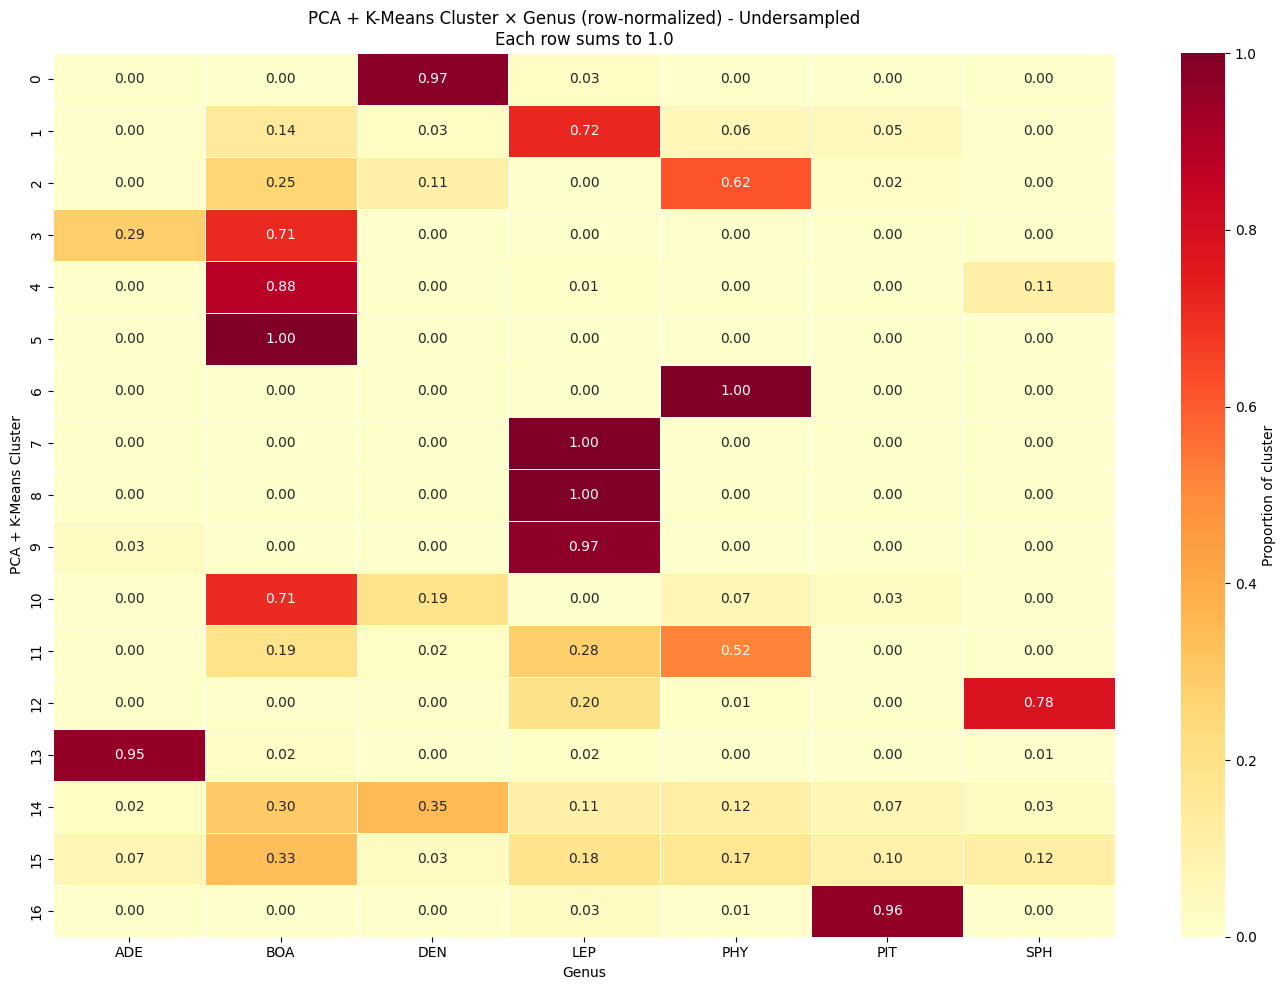


Clusters with >90% single genus (PCA + K-Means): 8
Clusters with >75% single genus (PCA + K-Means): 10
Clusters with <50% single genus (PCA + K-Means): 2  ← these are the messy ones


In [ ]:
import seaborn as sns

ct_pca = pd.crosstab(meta_train['kmeans_pca_cluster'], meta_train['species'])
print(f"\nCluster × Species matrix (top 10 clusters for PCA + K-Means):")
print(ct_pca.head(10))

# ── Cluster × Genus Heatmap and Purity Analysis for PCA + K-Means ───────────────────────────
# Ensure 'genus' column exists
if 'genus' not in meta_train.columns:
    meta_train['genus'] = meta_train['species'].str[:3]

print("\nGenus distribution (PCA + K-Means):")
print(meta_train['genus'].value_counts())

ct_genus_pca = pd.crosstab(
    meta_train['kmeans_pca_cluster'],
    meta_train['genus'],
    normalize='index'
)

plt.figure(figsize=(14, 10))
sns.heatmap(
    ct_genus_pca,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Proportion of cluster'}
)
plt.title('PCA + K-Means Cluster × Genus (row-normalized) - Undersampled\nEach row sums to 1.0')
plt.xlabel('Genus')
plt.ylabel('PCA + K-Means Cluster')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/pca_kmeans_cluster_genus_heatmap_undersampled.png', dpi=150)
plt.show()

ct_genus_raw_pca = pd.crosstab(meta_train['kmeans_pca_cluster'], meta_train['genus'])
dominant_proportion_pca = ct_genus_pca.max(axis=1)

print(f"\nClusters with >90% single genus (PCA + K-Means): {(dominant_proportion_pca > 0.9).sum()}")
print(f"Clusters with >75% single genus (PCA + K-Means): {(dominant_proportion_pca > 0.75).sum()}")
print(f"Clusters with <50% single genus (PCA + K-Means): {(dominant_proportion_pca < 0.5).sum()}  ← these are the messy ones")


Clusters found (PCA + K-Means): 17
Species in train: 17

── Dominant Species per PCA + K-Means Cluster ────────────────────────────
                   dominant_species  dominant_count  total_count  hit_ratio
kmeans_pca_cluster                                                         
8                            LEPPOD             149          149   1.000000
6                            PHYALB             171          171   1.000000
7                            LEPFUS             111          111   1.000000
5                            BOAFAB             126          126   1.000000
0                            DENMIN             180          185   0.972973
9                            LEPNOT              90           93   0.967742
16                           PITAZU             140          146   0.958904
13                           ADEMAR             127          133   0.954887
4                            BOABIS             187          213   0.877934
12                           SP

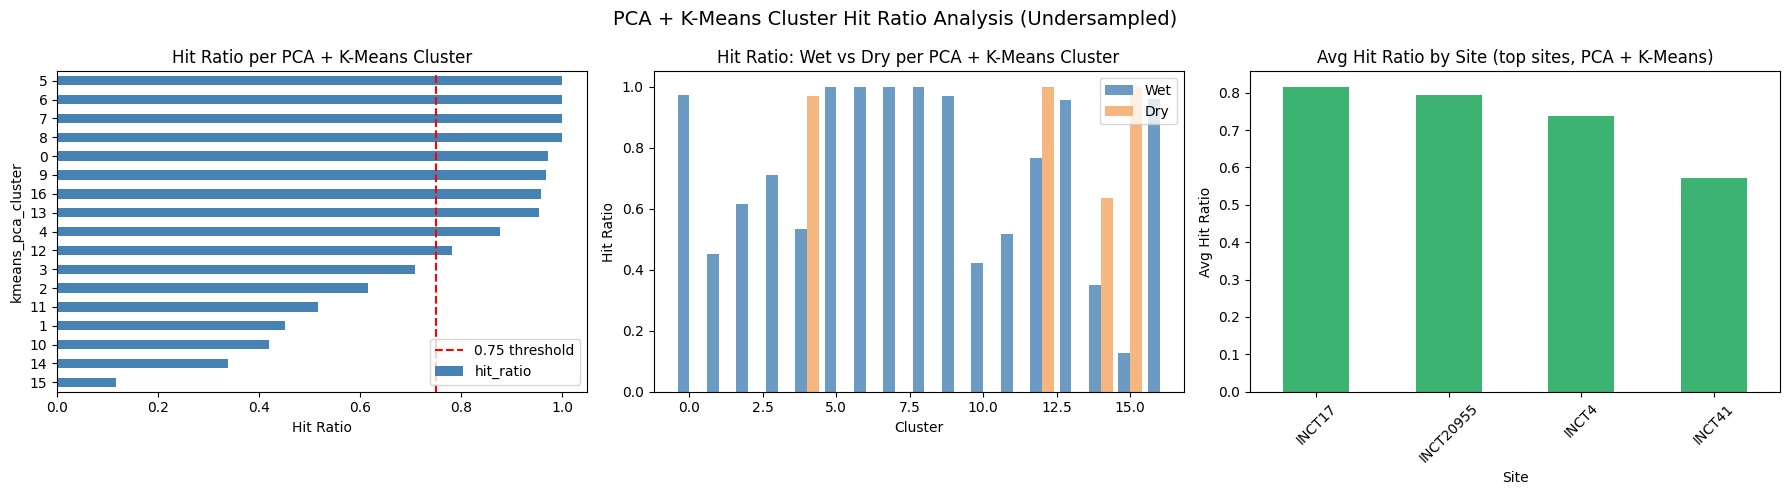

In [ ]:
# ── Dominant Species per Cluster and Hit Ratio Analysis for PCA + K-Means ───────────────────
n_clusters_pca = meta_train['kmeans_pca_cluster'].nunique()
n_species  = meta_train['species'].nunique()
print(f"\nClusters found (PCA + K-Means): {n_clusters_pca}")
print(f"Species in train: {n_species}")

ct_raw_pca = pd.crosstab(meta_train['kmeans_pca_cluster'], meta_train['species'])

cluster_summary_pca = pd.DataFrame({
    'dominant_species': ct_raw_pca.idxmax(axis=1),
    'dominant_count':   ct_raw_pca.max(axis=1),
    'total_count':      ct_raw_pca.sum(axis=1),
})
cluster_summary_pca['hit_ratio'] = (
    cluster_summary_pca['dominant_count'] / cluster_summary_pca['total_count']
)
cluster_summary_pca = cluster_summary_pca.sort_values('hit_ratio', ascending=False)

print(f"\n── Dominant Species per PCA + K-Means Cluster ────────────────────────────")
print(cluster_summary_pca.to_string())

print(f"\n── Species with highest PCA + K-Means cluster dominance ──────────────────")
species_hit_pca = cluster_summary_pca.groupby('dominant_species')['hit_ratio'].max()
print(species_hit_pca.sort_values(ascending=False).to_string())

print(f"\n── Hit ratio by season (PCA + K-Means) ─────────────────────────────────────")
for season_val, season_name in [(1, 'Wet'), (0, 'Dry')]:
    mask = meta_train['is_wet_season'] == season_val
    ct_s = pd.crosstab(
        meta_train[mask]['kmeans_pca_cluster'],
        meta_train[mask]['species']
    )
    if ct_s.empty:
        continue
    hit = (ct_s.max(axis=1) / ct_s.sum(axis=1)).mean()
    print(f"  {season_name} season avg hit ratio: {hit:.4f}")

print(f"\n── Hit ratio by site (top 10 sites, PCA + K-Means) ────────────────────────")
site_hits_pca = []
for site in meta_train['site'].value_counts().head(10).index:
    mask = meta_train['site'] == site
    ct_s = pd.crosstab(
        meta_train[mask]['kmeans_pca_cluster'],
        meta_train[mask]['species']
    )
    if ct_s.empty:
        continue
    hit = (ct_s.max(axis=1) / ct_s.sum(axis=1)).mean()
    site_hits_pca.append({'site': site, 'avg_hit_ratio': hit, 'n_samples': mask.sum()})

site_df_pca = pd.DataFrame(site_hits_pca).sort_values('avg_hit_ratio', ascending=False)
print(site_df_pca.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PCA + K-Means Cluster Hit Ratio Analysis (Undersampled)', fontsize=14)

cluster_summary_pca['hit_ratio'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].axvline(0.75, color='red', linestyle='--', label='0.75 threshold')
axes[0].set_title('Hit Ratio per PCA + K-Means Cluster')
axes[0].set_xlabel('Hit Ratio')
axes[0].legend()

wet_hits, dry_hits = [], []
for c in sorted(meta_train['kmeans_pca_cluster'].unique()):
    for season_val, store in [(1, wet_hits), (0, dry_hits)]:
        mask = (meta_train['kmeans_pca_cluster'] == c) & (meta_train['is_wet_season'] == season_val)
        sub = meta_train[mask]
        if len(sub) == 0:
            store.append(np.nan)
            continue
        ct_s = pd.crosstab(sub['kmeans_pca_cluster'], sub['species'])
        store.append((ct_s.max(axis=1) / ct_s.sum(axis=1)).mean())

x = np.arange(n_clusters_pca)
axes[1].bar(x - 0.2, wet_hits, 0.4, label='Wet', color='steelblue', alpha=0.8)
axes[1].bar(x + 0.2, dry_hits, 0.4, label='Dry', color='sandybrown', alpha=0.8)
axes[1].set_title('Hit Ratio: Wet vs Dry per PCA + K-Means Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Hit Ratio')
axes[1].legend()

site_df_pca.plot(kind='bar', x='site', y='avg_hit_ratio', ax=axes[2],
             color='mediumseagreen', legend=False)
axes[2].set_title('Avg Hit Ratio by Site (top sites, PCA + K-Means)')
axes[2].set_xlabel('Site')
axes[2].set_ylabel('Avg Hit Ratio')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ribbit/pca_kmeans_hit_ratio_analysis_undersampled.png', dpi=150)
plt.show()


── BOAALB deep dive (PCA + K-Means) ──────────────────────────────────────────
BOAALB total samples: 200
BOAALB clusters it appears in (PCA + K-Means): 4
BOAALB as dominant in N clusters (PCA + K-Means): 1

Sample distribution across PCA + K-Means clusters:
kmeans_pca_cluster
2      30
10    145
14     20
15      5
Name: count, dtype: int64

Season breakdown (PCA + K-Means):
is_wet_season
wet    200
Name: count, dtype: int64

Site breakdown (PCA + K-Means):
site
INCT41    200
Name: count, dtype: int64

── Sample count vs cluster spread (PCA + K-Means) ──────────────────────────
species  n_samples  hit_ratio  n_clusters_spread
 BOAALB        200      0.725                  4
 BOAFAB        200      0.630                  8
 BOABIS        200      0.935                  4
 SPHSUR        200      0.790                  6
 LEPPOD        200      0.745                  6
 PHYCUV        200      0.690                  5
 BOALUN        200      0.495                  4
 PHYALB        200    

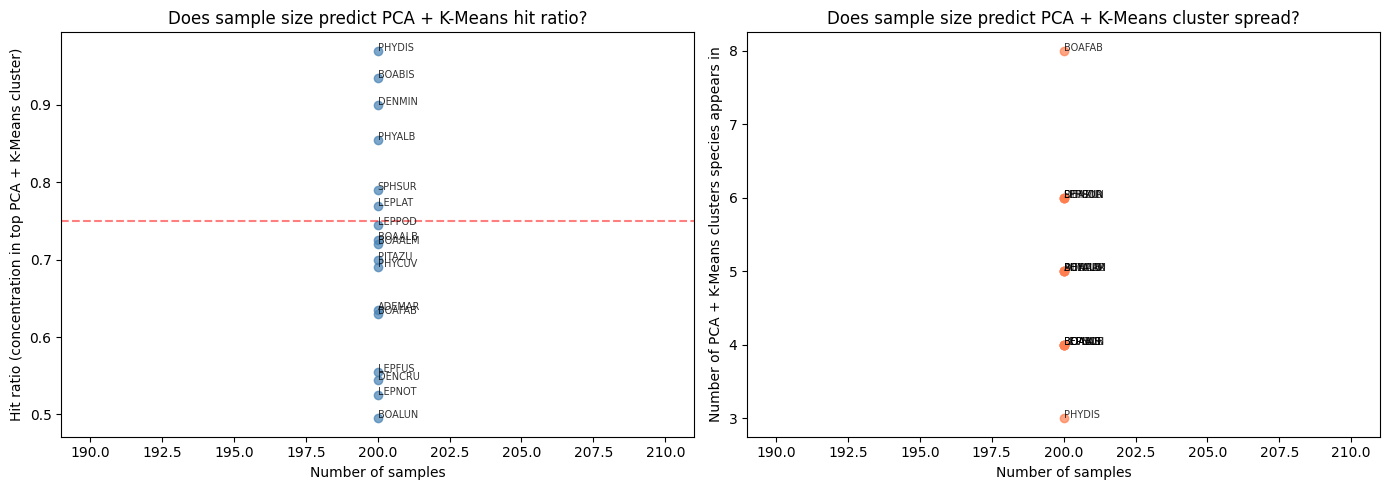


── Correlations (PCA + K-Means) ────────────────────────────────────────────
                   n_samples  n_clusters_spread  hit_ratio
n_samples                NaN                NaN        NaN
n_clusters_spread        NaN              1.000     -0.074
hit_ratio                NaN             -0.074      1.000


In [ ]:
# ── Species-level Deep Dive and Correlation Analysis (PCA + K-Means) ──────────────────────────
species_to_analyze_pca = meta_train['species'].value_counts().index[0]

boafab_pca = meta_train[meta_train['species'] == species_to_analyze_pca].copy()

print(f"\n── {species_to_analyze_pca} deep dive (PCA + K-Means) ──────────────────────────────────────────")
print(f"{species_to_analyze_pca} total samples: {len(boafab_pca)}")
print(f"{species_to_analyze_pca} clusters it appears in (PCA + K-Means): {boafab_pca['kmeans_pca_cluster'].nunique()}")
print(f"{species_to_analyze_pca} as dominant in N clusters (PCA + K-Means): {(cluster_summary_pca['dominant_species'] == species_to_analyze_pca).sum()}")

print(f"\nSample distribution across PCA + K-Means clusters:")
print(boafab_pca['kmeans_pca_cluster'].value_counts().sort_index())

print(f"\nSeason breakdown (PCA + K-Means):")
print(boafab_pca['is_wet_season'].value_counts().rename({1:'wet', 0:'dry'}))

print(f"\nSite breakdown (PCA + K-Means):")
print(boafab_pca['site'].value_counts())

species_stats_pca = []
for sp in meta_train['species'].unique():
    sp_mask = meta_train['species'] == sp
    n = sp_mask.sum()
    sp_clusters = meta_train[sp_mask]['kmeans_pca_cluster'].value_counts()
    if len(sp_clusters) > 0:
      hit = sp_clusters.iloc[0] / n
    else:
      hit = 0.0 # No clusters found for this species
    n_clusters_in = len(sp_clusters)
    species_stats_pca.append({
        'species': sp,
        'n_samples': n,
        'hit_ratio': hit,
        'n_clusters_spread': n_clusters_in
    })

stats_df_pca = pd.DataFrame(species_stats_pca).sort_values('n_samples', ascending=False)
print(f"\n── Sample count vs cluster spread (PCA + K-Means) ──────────────────────────")
print(stats_df_pca.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(stats_df_pca['n_samples'], stats_df_pca['hit_ratio'], alpha=0.7, color='steelblue')
for _, row in stats_df_pca.iterrows():
    axes[0].annotate(row['species'],
                     (row['n_samples'], row['hit_ratio']),
                     fontsize=7, alpha=0.8)
axes[0].axhline(0.75, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Number of samples')
axes[0].set_ylabel('Hit ratio (concentration in top PCA + K-Means cluster)')
axes[0].set_title('Does sample size predict PCA + K-Means hit ratio?')

axes[1].scatter(stats_df_pca['n_samples'], stats_df_pca['n_clusters_spread'], alpha=0.7, color='coral')
for _, row in stats_df_pca.iterrows():
    axes[1].annotate(row['species'],
                     (row['n_samples'], row['n_clusters_spread']),
                     fontsize=7, alpha=0.8)
axes[1].set_xlabel('Number of samples')
axes[1].set_ylabel('Number of PCA + K-Means clusters species appears in')
axes[1].set_title('Does sample size predict PCA + K-Means cluster spread?')

plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/ribbit/{species_to_analyze_pca}_pca_kmeans_diagnosis_undersampled.png', dpi=150)
plt.show()

corr_pca = stats_df_pca[['n_samples', 'n_clusters_spread', 'hit_ratio']].corr()
print(f"\n── Correlations (PCA + K-Means) ────────────────────────────────────────────")
print(corr_pca.round(3))

## Optimizing the Number of PCA Components

To find the optimal number of PCA components, we will systematically test a range of component counts. For each count, we will perform PCA, apply K-Means clustering, and evaluate the results using Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI). This will help us identify the dimensionality that best preserves the cluster structure.

Optimizing PCA components for K-Means clustering...
  Testing 50 components...
  Testing 60 components...
  Testing 70 components...
  Testing 80 components...
  Testing 90 components...
  Testing 100 components...
  Testing 110 components...
  Testing 120 components...
  Testing 130 components...
  Testing 140 components...
  Testing 150 components...
  Testing 160 components...
  Testing 170 components...
  Testing 180 components...
  Testing 190 components...
  Testing 200 components...
  Testing 210 components...
  Testing 220 components...
  Testing 230 components...
  Testing 240 components...
  Testing 250 components...
  Testing 260 components...
  Testing 270 components...
  Testing 280 components...
  Testing 290 components...
  Testing 300 components...
Optimization complete!


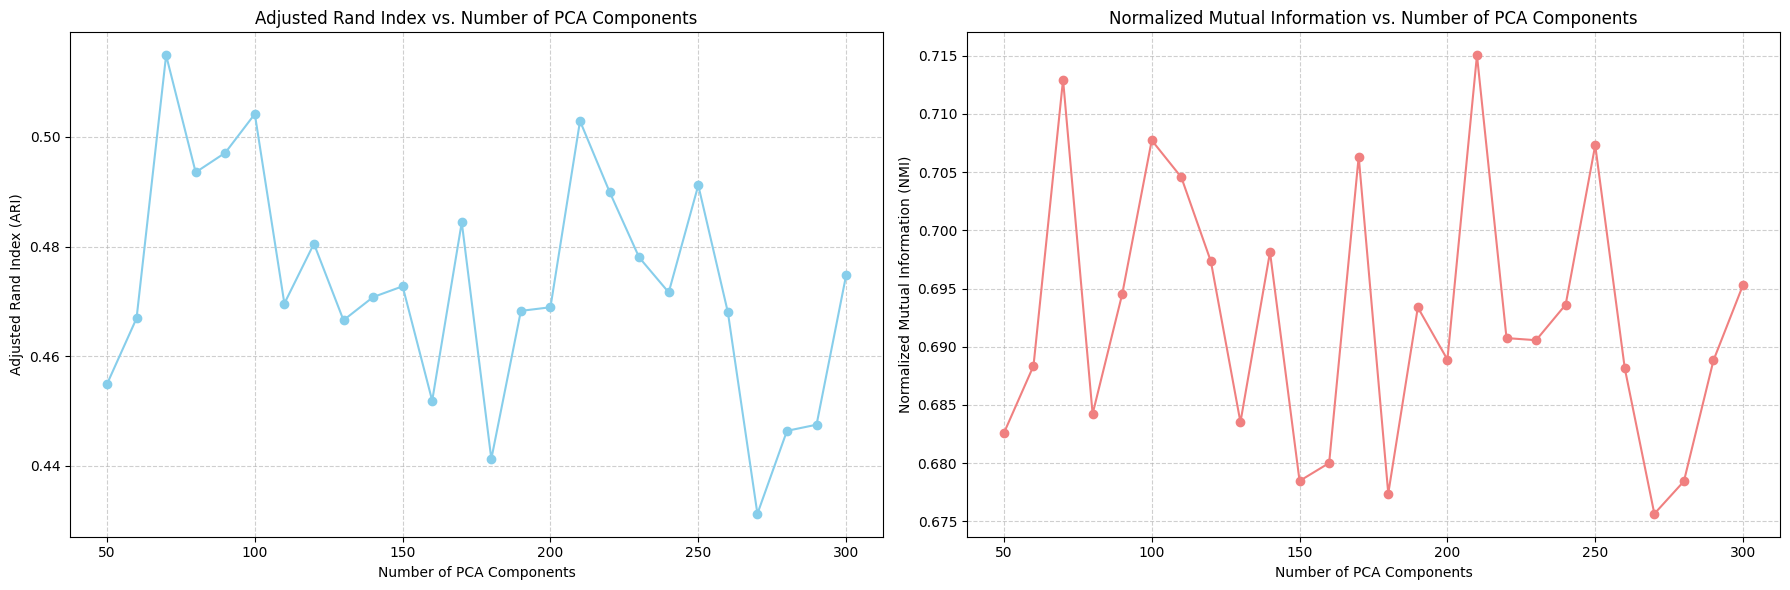

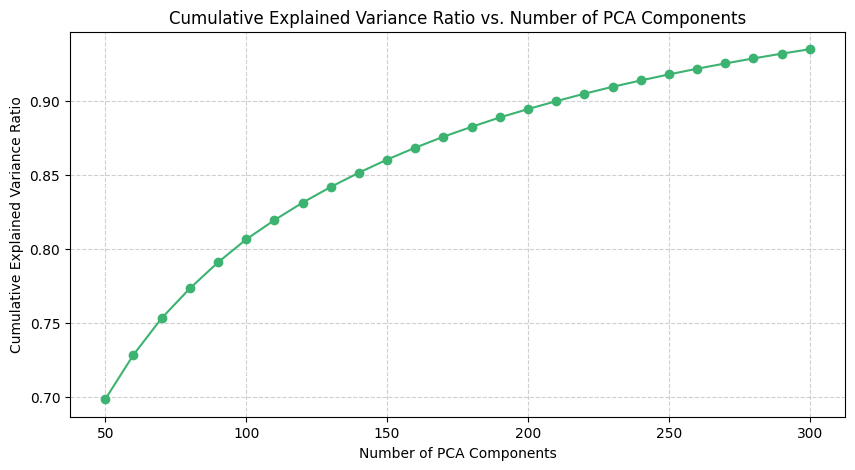


Best ARI achieved with 70 components: 0.5149
Best NMI achieved with 210 components: 0.7150


In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
import numpy as np

n_components_range = range(50, 301, 10)

ari_scores = []
nmi_scores = []
explained_variance_ratios = []

k = meta_train['species'].nunique()
true_labels = pd.Categorical(meta_train['species']).codes

print("Optimizing PCA components for K-Means clustering...")
for n_comp in n_components_range:
    print(f"  Testing {n_comp} components...")
    pca_model = PCA(n_components=n_comp, random_state=42)
    X_train_pca_opt = pca_model.fit_transform(X_train)

    explained_variance_ratios.append(pca_model.explained_variance_ratio_.sum())
    kmeans_pca_opt = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters_pca_opt = kmeans_pca_opt.fit_predict(X_train_pca_opt)

    ari = adjusted_rand_score(true_labels, clusters_pca_opt)
    nmi = normalized_mutual_info_score(true_labels, clusters_pca_opt)

    ari_scores.append(ari)
    nmi_scores.append(nmi)

print("Optimization complete!")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot ARI scores
ax1.plot(list(n_components_range), ari_scores, marker='o', linestyle='-', color='skyblue')
ax1.set_title('Adjusted Rand Index vs. Number of PCA Components')
ax1.set_xlabel('Number of PCA Components')
ax1.set_ylabel('Adjusted Rand Index (ARI)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot NMI scores
ax2.plot(list(n_components_range), nmi_scores, marker='o', linestyle='-', color='lightcoral')
ax2.set_title('Normalized Mutual Information vs. Number of PCA Components')
ax2.set_xlabel('Number of PCA Components')
ax2.set_ylabel('Normalized Mutual Information (NMI)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Plot explained variance ratio
plt.figure(figsize=(10, 5))
plt.plot(list(n_components_range), explained_variance_ratios, marker='o', linestyle='-', color='mediumseagreen')
plt.title('Cumulative Explained Variance Ratio vs. Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Find the n_components that yielded the highest ARI and NMI
best_ari_n_comp = list(n_components_range)[np.argmax(ari_scores)]
best_nmi_n_comp = list(n_components_range)[np.argmax(nmi_scores)]

print(f"\nBest ARI achieved with {best_ari_n_comp} components: {max(ari_scores):.4f}")
print(f"Best NMI achieved with {best_nmi_n_comp} components: {max(nmi_scores):.4f}")

In [ ]:
model_performance = pd.DataFrame(columns=['Model', 'ARI', 'NMI', 'Purity', 'Notes'])

# Add initial K-Means (Undersampled, High-Dim) results from cell rCNBktcuXDcX
model_performance.loc[len(model_performance)] = ['K-Means (Undersampled, High-Dim)', 0.4638, 0.6996, 0.6459, 'Undersampled data, 1024 dimensions']

# Add GMM (Undersampled, High-Dim) results from cell a1b220d2
model_performance.loc[len(model_performance)] = ['GMM (Undersampled, High-Dim)', 0.4666, 0.6847, 0.6591, 'Undersampled data, 1024 dimensions']

# Add PCA (100) + K-Means (Undersampled) results from cell 9e87b89b
model_performance.loc[len(model_performance)] = ['PCA (100) + K-Means (Undersampled)', 0.5042, 0.7077, 0.6853, '100 PCA components']

display(model_performance)

,Model,ARI,NMI,Purity,Notes
0,"K-Means (Undersampled, High-Dim)",0.4638,0.6996,0.6459,"Undersampled data, 1024 dimensions"
1,"GMM (Undersampled, High-Dim)",0.4666,0.6847,0.6591,"Undersampled data, 1024 dimensions"
2,PCA (100) + K-Means (Undersampled),0.5042,0.7077,0.6853,100 PCA components


### Re-running PCA + K-Means with 70 Components (Optimal ARI)

In [ ]:
n_components_opt_kmeans = 70

print(f"\nPerforming PCA to reduce dimensionality to {n_components_opt_kmeans} components...")
pca_model_opt_kmeans = PCA(n_components=n_components_opt_kmeans, random_state=42)
X_train_pca_opt_kmeans = pca_model_opt_kmeans.fit_transform(X_train)
print(f"Explained variance with {n_components_opt_kmeans} components: {pca_model_opt_kmeans.explained_variance_ratio_.sum()*100:.1f}%")

k = meta_train['species'].nunique()
print(f"\nFitting K-Means with k={k} on PCA-transformed train set (n_components={n_components_opt_kmeans})...")

kmeans_pca_opt_model = KMeans(n_clusters=k, random_state=42, n_init=10)
meta_train['kmeans_pca_opt_cluster'] = kmeans_pca_opt_model.fit_predict(X_train_pca_opt_kmeans)
print(f"Done! Inertia: {kmeans_pca_opt_model.inertia_:.2f}")

true_labels = pd.Categorical(meta_train['species']).codes
ari_pca_opt_kmeans  = adjusted_rand_score(true_labels, meta_train['kmeans_pca_opt_cluster'])
nmi_pca_opt_kmeans  = normalized_mutual_info_score(true_labels, meta_train['kmeans_pca_opt_cluster'])
purity_pca_opt_kmeans = purity_score(true_labels, meta_train['kmeans_pca_opt_cluster'])

print(f"\n── PCA ({n_components_opt_kmeans}) + K-Means Cluster Purity (train) ──────────────────")
print(f"  Adjusted Rand Index (ARI): {ari_pca_opt_kmeans:.4f}  (1.0 = perfect)")
print(f"  Normalized Mutual Info:    {nmi_pca_opt_kmeans:.4f}  (1.0 = perfect)")
print(f"  Purity Score:              {purity_pca_opt_kmeans:.4f}  (1.0 = perfect)")

# Add to model performance log
model_performance.loc[len(model_performance)] = [f'PCA ({n_components_opt_kmeans}) + K-Means (Undersampled)', ari_pca_opt_kmeans, nmi_pca_opt_kmeans, purity_pca_opt_kmeans, f'{n_components_opt_kmeans} PCA components']

display(model_performance)


Performing PCA to reduce dimensionality to 70 components...
Explained variance with 70 components: 75.3%

Fitting K-Means with k=17 on PCA-transformed train set (n_components=70)...
Done! Inertia: 220059.57

── PCA (70) + K-Means Cluster Purity (train) ──────────────────
  Adjusted Rand Index (ARI): 0.5149  (1.0 = perfect)
  Normalized Mutual Info:    0.7129  (1.0 = perfect)
  Purity Score:              0.6826  (1.0 = perfect)


,Model,ARI,NMI,Purity,Notes
0,"K-Means (Undersampled, High-Dim)",0.463800,0.699600,0.645900,"Undersampled data, 1024 dimensions"
1,"GMM (Undersampled, High-Dim)",0.466600,0.684700,0.659100,"Undersampled data, 1024 dimensions"
2,PCA (100) + K-Means (Undersampled),0.504200,0.707700,0.685300,100 PCA components
3,PCA (70) + K-Means (Undersampled),0.514883,0.712943,0.682647,70 PCA components


### Optimizing PCA Components for GMM Clustering

Optimizing PCA components for GMM clustering...
  Testing 50 components...
  Testing 60 components...
  Testing 70 components...
  Testing 80 components...
  Testing 90 components...
  Testing 100 components...
  Testing 110 components...
  Testing 120 components...
  Testing 130 components...
  Testing 140 components...
  Testing 150 components...
  Testing 160 components...
  Testing 170 components...
  Testing 180 components...
  Testing 190 components...
  Testing 200 components...
  Testing 210 components...
  Testing 220 components...
  Testing 230 components...
  Testing 240 components...
  Testing 250 components...
  Testing 260 components...
  Testing 270 components...
  Testing 280 components...
  Testing 290 components...
  Testing 300 components...
Optimization complete!


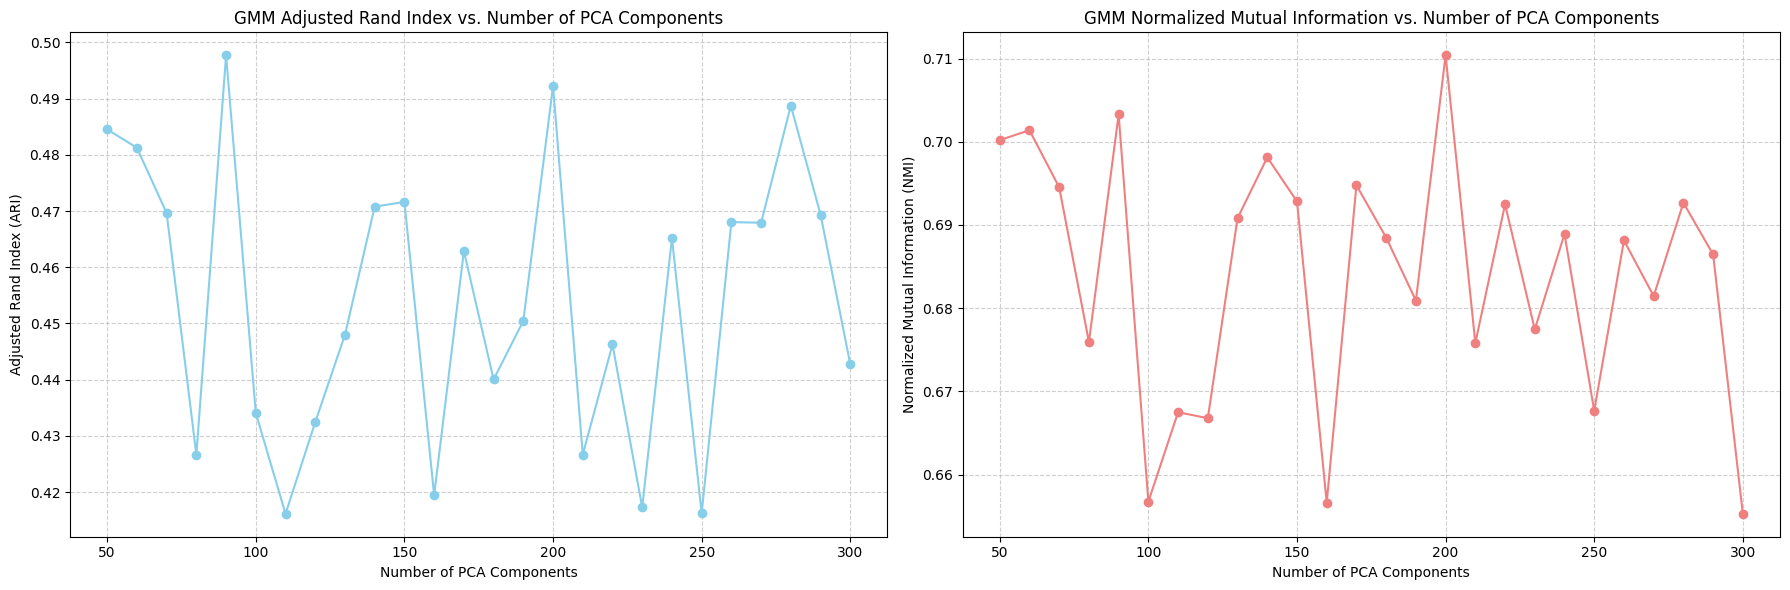

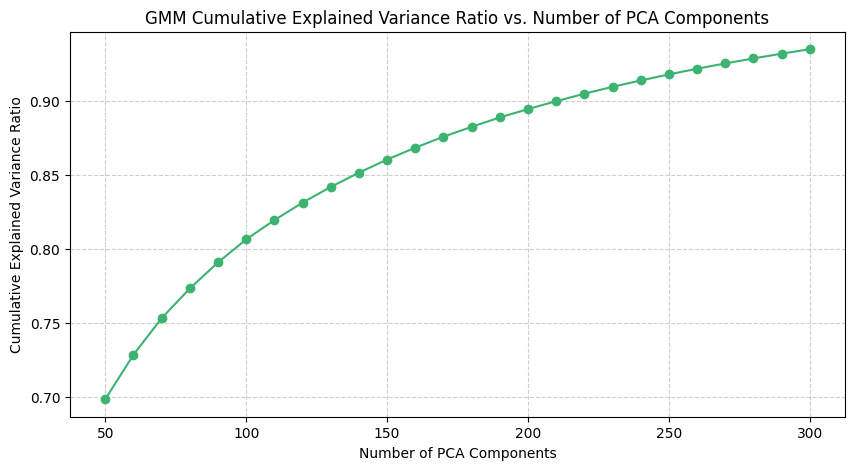


Best GMM ARI achieved with 90 components: 0.4977
Best GMM NMI achieved with 200 components: 0.7104


In [ ]:
n_components_range_gmm = range(50, 301, 10)

ari_scores_gmm = []
nmi_scores_gmm = []
explained_variance_ratios_gmm = []

k = meta_train['species'].nunique()
true_labels = pd.Categorical(meta_train['species']).codes

print("Optimizing PCA components for GMM clustering...")
for n_comp in n_components_range_gmm:
    print(f"  Testing {n_comp} components...")
    pca_model_gmm = PCA(n_components=n_comp, random_state=42)
    X_train_pca_gmm_opt = pca_model_gmm.fit_transform(X_train)

    explained_variance_ratios_gmm.append(pca_model_gmm.explained_variance_ratio_.sum())
    gmm_pca_opt = GaussianMixture(n_components=k, random_state=42, n_init=10, covariance_type='full')
    clusters_pca_gmm_opt = gmm_pca_opt.fit_predict(X_train_pca_gmm_opt)

    ari = adjusted_rand_score(true_labels, clusters_pca_gmm_opt)
    nmi = normalized_mutual_info_score(true_labels, clusters_pca_gmm_opt)

    ari_scores_gmm.append(ari)
    nmi_scores_gmm.append(nmi)

print("Optimization complete!")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot ARI scores
ax1.plot(list(n_components_range_gmm), ari_scores_gmm, marker='o', linestyle='-', color='skyblue')
ax1.set_title('GMM Adjusted Rand Index vs. Number of PCA Components')
ax1.set_xlabel('Number of PCA Components')
ax1.set_ylabel('Adjusted Rand Index (ARI)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot NMI scores
ax2.plot(list(n_components_range_gmm), nmi_scores_gmm, marker='o', linestyle='-', color='lightcoral')
ax2.set_title('GMM Normalized Mutual Information vs. Number of PCA Components')
ax2.set_xlabel('Number of PCA Components')
ax2.set_ylabel('Normalized Mutual Information (NMI)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Plot explained variance ratio
plt.figure(figsize=(10, 5))
plt.plot(list(n_components_range_gmm), explained_variance_ratios_gmm,
         marker='o', linestyle='-', color='mediumseagreen')
plt.title('GMM Cumulative Explained Variance Ratio vs. Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Find the n_components that yielded the highest ARI and NMI for GMM
best_ari_n_comp_gmm = list(n_components_range_gmm)[np.argmax(ari_scores_gmm)]
best_nmi_n_comp_gmm = list(n_components_range_gmm)[np.argmax(nmi_scores_gmm)]

print(f"\nBest GMM ARI achieved with {best_ari_n_comp_gmm} components: {max(ari_scores_gmm):.4f}")
print(f"Best GMM NMI achieved with {best_nmi_n_comp_gmm} components: {max(nmi_scores_gmm):.4f}")

### Running PCA + GMM with Optimal Components

In [ ]:
# Use the number of components that gave the best ARI for GMM
n_components_opt_gmm = best_ari_n_comp_gmm # Or best_nmi_n_comp_gmm, depending on primary metric

print(f"\nPerforming PCA to reduce dimensionality to {n_components_opt_gmm} components for GMM...")
pca_model_opt_gmm = PCA(n_components=n_components_opt_gmm, random_state=42)
X_train_pca_opt_gmm = pca_model_opt_gmm.fit_transform(X_train)
print(f"Explained variance with {n_components_opt_gmm} components: {pca_model_opt_gmm.explained_variance_ratio_.sum()*100:.1f}%")

k = meta_train['species'].nunique()
print(f"\nFitting GMM with k={k} on PCA-transformed train set (n_components={n_components_opt_gmm})...")

gmm_pca_opt_model = GaussianMixture(n_components=k, random_state=42, n_init=10, covariance_type='full')
meta_train['gmm_pca_opt_cluster'] = gmm_pca_opt_model.fit_predict(X_train_pca_opt_gmm)
print(f"Done! Log-likelihood lower bound: {gmm_pca_opt_model.lower_bound_:.2f}")

true_labels = pd.Categorical(meta_train['species']).codes
ari_pca_opt_gmm  = adjusted_rand_score(true_labels, meta_train['gmm_pca_opt_cluster'])
nmi_pca_opt_gmm  = normalized_mutual_info_score(true_labels, meta_train['gmm_pca_opt_cluster'])
purity_pca_opt_gmm = purity_score(true_labels, meta_train['gmm_pca_opt_cluster'])

print(f"\n── PCA ({n_components_opt_gmm}) + GMM Cluster Purity (train) ──────────────────")
print(f"  Adjusted Rand Index (ARI): {ari_pca_opt_gmm:.4f}  (1.0 = perfect)")
print(f"  Normalized Mutual Info:    {nmi_pca_opt_gmm:.4f}  (1.0 = perfect)")
print(f"  Purity Score:              {purity_pca_opt_gmm:.4f}  (1.0 = perfect)")

# Add to model performance log
model_performance.loc[len(model_performance)] = [f'PCA ({n_components_opt_gmm}) + GMM (Undersampled)', ari_pca_opt_gmm, nmi_pca_opt_gmm, purity_pca_opt_gmm, f'{n_components_opt_gmm} PCA components']

display(model_performance.sort_values(by='ARI', ascending=False))


Performing PCA to reduce dimensionality to 90 components for GMM...
Explained variance with 90 components: 79.1%

Fitting GMM with k=17 on PCA-transformed train set (n_components=90)...
Done! Log-likelihood lower bound: -30.13

── PCA (90) + GMM Cluster Purity (train) ──────────────────
  Adjusted Rand Index (ARI): 0.4977  (1.0 = perfect)
  Normalized Mutual Info:    0.7033  (1.0 = perfect)
  Purity Score:              0.6518  (1.0 = perfect)


,Model,ARI,NMI,Purity,Notes
3,PCA (70) + K-Means (Undersampled),0.514883,0.712943,0.682647,70 PCA components
2,PCA (100) + K-Means (Undersampled),0.504200,0.707700,0.685300,100 PCA components
4,PCA (90) + GMM (Undersampled),0.497696,0.703290,0.651765,90 PCA components
1,"GMM (Undersampled, High-Dim)",0.466600,0.684700,0.659100,"Undersampled data, 1024 dimensions"
0,"K-Means (Undersampled, High-Dim)",0.463800,0.699600,0.645900,"Undersampled data, 1024 dimensions"


### Visualize PCA + GMM results with optimal components


Explained variance for 2D visualization: 19.4%


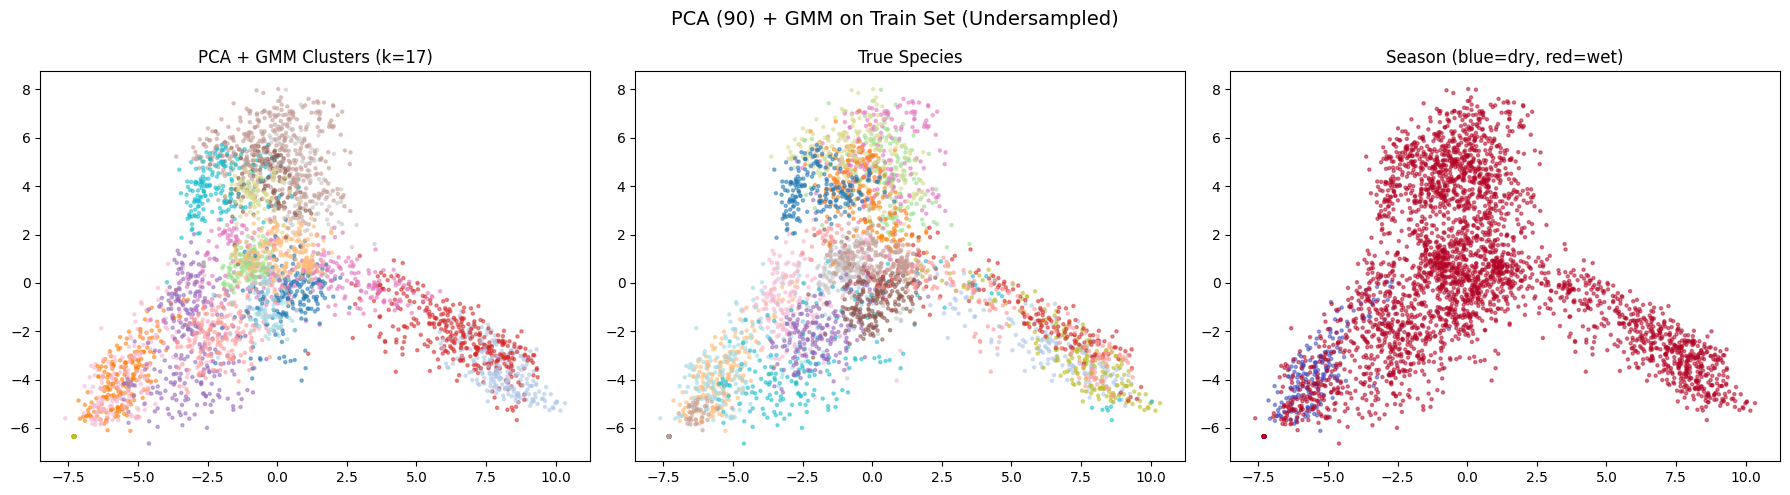

In [ ]:
# Visualize PCA + GMM results

# Reduce X_train_pca_opt_gmm to 2 dimensions for visualization only
pca_viz_gmm = PCA(n_components=2, random_state=42)
X_train_pca_gmm_2d = pca_viz_gmm.fit_transform(X_train_pca_opt_gmm)
print(f"\nExplained variance for 2D visualization: {pca_viz_gmm.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'PCA ({n_components_opt_gmm}) + GMM on Train Set (Undersampled)', fontsize=14)

species_codes = pd.Categorical(meta_train['species']).codes
k_gmm = meta_train['species'].nunique() # Number of clusters for GMM

axes[0].scatter(X_train_pca_gmm_2d[:,0], X_train_pca_gmm_2d[:,1], c=meta_train['gmm_pca_opt_cluster'],
                cmap='tab20', s=5, alpha=0.5)
axes[0].set_title(f'PCA + GMM Clusters (k={k_gmm})')

axes[1].scatter(X_train_pca_gmm_2d[:,0], X_train_pca_gmm_2d[:,1], c=species_codes,
                cmap='tab20', s=5, alpha=0.5)
axes[1].set_title('True Species')

axes[2].scatter(X_train_pca_gmm_2d[:,0], X_train_pca_gmm_2d[:,1], c=meta_train['is_wet_season'],
                cmap='coolwarm', s=5, alpha=0.5)
axes[2].set_title('Season (blue=dry, red=wet)')

plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/ribbit/pca_{n_components_opt_gmm}_gmm_train_purity_undersampled.png', dpi=150)
plt.show()

# Systematic Evaluation of Clustering Strategies


In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.model_selection import train_test_split

def purity_score(labels_true, labels_pred):
    ct = pd.crosstab(labels_pred, labels_true)
    return ct.max(axis=1).sum() / len(labels_true)

# 1. Helper function to run PCA + Clustering and evaluate
def run_and_evaluate_clustering(X_data, meta_data, n_pca_components, clustering_model_type, random_state=42):
    k = meta_data['species'].nunique()
    true_labels = pd.Categorical(meta_data['species']).codes

    # Perform PCA if n_pca_components is not None, otherwise use original data
    if n_pca_components is not None:
        pca_model = PCA(n_components=n_pca_components, random_state=random_state)
        X_processed = pca_model.fit_transform(X_data)
        explained_variance_sum = pca_model.explained_variance_ratio_.sum()
    else:
        X_processed = X_data
        explained_variance_sum = 1.0 # no reducation

    # Perform Clustering
    if clustering_model_type == 'kmeans':
        cluster_model = KMeans(n_clusters=k, random_state=random_state, n_init=10)

    elif clustering_model_type == 'gmm':

        cluster_model = GaussianMixture(n_components=k, random_state=random_state, n_init=10, covariance_type='full')

    else:
        raise ValueError("clustering_model_type must be 'kmeans' or 'gmm'")

    clusters = cluster_model.fit_predict(X_processed)

    ari = adjusted_rand_score(true_labels, clusters)
    nmi = normalized_mutual_info_score(true_labels, clusters)
    purity = purity_score(true_labels, clusters)

    return ari, nmi, purity, explained_variance_sum

# 2. Helper function to optimize PCA components
def optimize_pca_components(X_data, meta_data, clustering_model_type, n_components_range, random_state=42):
    best_ari = -1
    best_n_components = -1
    best_nmi = -1
    best_purity = -1
    best_explained_variance = -1

    print(f"Optimizing PCA components for {clustering_model_type.upper()} clustering...")
    for n_comp in n_components_range:
        ari, nmi, purity, explained_variance = run_and_evaluate_clustering(
            X_data, meta_data, n_comp, clustering_model_type, random_state
        )
        if ari > best_ari:
            best_ari = ari
            best_n_components = n_comp
            best_nmi = nmi
            best_purity = purity
            best_explained_variance = explained_variance

    print(f"  Best {clustering_model_type.upper()} ARI: {best_ari:.4f} with {best_n_components} components.")
    return best_n_components, best_ari, best_nmi, best_purity, best_explained_variance

# main execution
model_performance = pd.DataFrame(columns=['Model', 'ARI', 'NMI', 'Purity', 'Notes'])
n_components_range = range(50, 251, 20)
random_state = 42

# Sampling strategies

# Undersampled data
if 'X_train' not in locals() or 'meta_train' not in locals():
    print("WARNING: X_train or meta_train (undersampled) not found. Re-creating them.")
    TRAIN_SAMPLES_PER_SPECIES = 200
    TEST_SAMPLES_PER_SPECIES = 50

    species_counts_original = metadata_df['species'].value_counts()

    required_total_samples = TRAIN_SAMPLES_PER_SPECIES + TEST_SAMPLES_PER_SPECIES
    valid_species_for_new_sampling = species_counts_original[
        species_counts_original >= required_total_samples
    ].index

    mask_valid_species = metadata_df['species'].isin(valid_species_for_new_sampling)
    metadata_filtered_new = metadata_df[mask_valid_species].reset_index(drop=True)
    embeddings_filtered_new = embeddings[mask_valid_species]

    X_train_list, X_test_list = [], []
    meta_train_list, meta_test_list = [], []

    for species_name in valid_species_for_new_sampling:
        species_mask = metadata_filtered_new['species'] == species_name
        X_species = embeddings_filtered_new[species_mask]
        meta_species = metadata_filtered_new[species_mask].reset_index(drop=True)

        if len(meta_species) < required_total_samples:
            continue

        indices = meta_species.index.tolist()
        train_samples_indices = np.random.choice(
            indices,
            size=TRAIN_SAMPLES_PER_SPECIES,
            replace=False
        )

        remaining_indices = [idx for idx in indices if idx not in train_samples_indices]

        test_samples_indices = np.random.choice(
            remaining_indices,
            size=TEST_SAMPLES_PER_SPECIES,
            replace=False
        )

        X_train_list.append(X_species[train_samples_indices])
        meta_train_list.append(meta_species.loc[train_samples_indices])

        X_test_list.append(X_species[test_samples_indices])
        meta_test_list.append(meta_species.loc[test_samples_indices])

    X_train = np.vstack(X_train_list)
    meta_train = pd.concat(meta_train_list).reset_index(drop=True)

current_X_train_undersampled = X_train
current_meta_train_undersampled = meta_train

# Stratified data > 100
if 'X_filtered' not in locals() or 'metadata_filtered' not in locals():
    print("WARNING: X_filtered or metadata_filtered not found. Re-running filtering steps.")
    species_counts = metadata_df['species'].value_counts()
    valid_species = species_counts[species_counts >= 100].index
    mask = metadata_df['species'].isin(valid_species)
    metadata_filtered = metadata_df[mask].reset_index(drop=True)
    X_filtered = embeddings[mask]

X_train_stratified, X_test_stratified, meta_train_stratified, meta_test_stratified = train_test_split(
    X_filtered,
    metadata_filtered,
    test_size=0.2,
    random_state=random_state,
    stratify=metadata_filtered['species']
)
meta_train_stratified = meta_train_stratified.reset_index(drop=True)
meta_test_stratified = meta_test_stratified.reset_index(drop=True)

sampling_strategies = {
    'undersampled': {'X_train': current_X_train_undersampled, 'meta_train': current_meta_train_undersampled, 'X_test': X_test_list, 'meta_test': meta_test_list}, # NOTE: X_test_list, meta_test_list from undersampling setup
    'stratified':   {'X_train': X_train_stratified, 'meta_train': meta_train_stratified, 'X_test': X_test_stratified, 'meta_test': meta_test_stratified}
}

clustering_algorithms = ['kmeans', 'gmm']

print("Starting systematic evaluation...")

# First, evaluate Non-PCA Baselines for both undersampled and stratified data
print("\n--- Evaluating Non-PCA Baselines ---")
for strategy_name, data_sets in sampling_strategies.items():
    X_current = data_sets['X_train']
    meta_current = data_sets['meta_train']
    for algo_name in clustering_algorithms:
        print(f"  Running {algo_name.upper()} on high-dimensional {strategy_name} data...")
        ari, nmi, purity, explained_variance = run_and_evaluate_clustering(
            X_current, meta_current, n_pca_components=None, clustering_model_type=algo_name, random_state=random_state
        )
        model_name = f'{algo_name.upper()} ({strategy_name.capitalize()}, High-Dim)'
        notes = 'No PCA reduction'
        model_performance.loc[len(model_performance)] = [
            model_name, ari, nmi, purity, notes
        ]

# Then, evaluate PCA-optimized models
for strategy_name, data_sets in sampling_strategies.items():
    X_current = data_sets['X_train']
    meta_current = data_sets['meta_train']

    for algo_name in clustering_algorithms:
        print(f"\n--- Strategy: {strategy_name.capitalize()}, Algorithm: {algo_name.upper()} (PCA Optimized) ---")

        # Optimize PCA components and get the best scores
        best_n_comp, best_ari, best_nmi, best_purity, best_explained_variance = optimize_pca_components(
            X_current, meta_current, algo_name, n_components_range, random_state
        )

        # Log results to the model_performance DataFrame
        model_name = f'PCA ({best_n_comp}) + {algo_name.upper()} ({strategy_name.capitalize()})'
        notes = f'{best_n_comp} PCA components, {best_explained_variance*100:.1f}% explained variance'

        model_performance.loc[len(model_performance)] = [
            model_name, best_ari, best_nmi, best_purity, notes
        ]

print("\nSystematic evaluation complete!")
display(model_performance.sort_values(by='ARI', ascending=False))

Starting systematic evaluation...

--- Evaluating Non-PCA Baselines ---
  Running KMEANS on high-dimensional undersampled data...
  Running GMM on high-dimensional undersampled data...
  Running KMEANS on high-dimensional stratified data...
  Running GMM on high-dimensional stratified data...

--- Strategy: Undersampled, Algorithm: KMEANS (PCA Optimized) ---
Optimizing PCA components for KMEANS clustering...
  Best KMEANS ARI: 0.5018 with 230 components.

--- Strategy: Undersampled, Algorithm: GMM (PCA Optimized) ---
Optimizing PCA components for GMM clustering...
  Best GMM ARI: 0.5215 with 50 components.

--- Strategy: Stratified, Algorithm: KMEANS (PCA Optimized) ---
Optimizing PCA components for KMEANS clustering...
  Best KMEANS ARI: 0.4358 with 70 components.

--- Strategy: Stratified, Algorithm: GMM (PCA Optimized) ---
Optimizing PCA components for GMM clustering...
  Best GMM ARI: 0.4746 with 50 components.

Systematic evaluation complete!


,Model,ARI,NMI,Purity,Notes
5,PCA (50) + GMM (Undersampled),0.521486,0.694922,0.661176,"50 PCA components, 69.8% explained variance"
4,PCA (230) + KMEANS (Undersampled),0.501793,0.691216,0.670588,"230 PCA components, 90.9% explained variance"
7,PCA (50) + GMM (Stratified),0.474589,0.682854,0.713061,"50 PCA components, 69.2% explained variance"
1,"GMM (Undersampled, High-Dim)",0.441674,0.670522,0.614706,No PCA reduction
0,"KMEANS (Undersampled, High-Dim)",0.439435,0.664024,0.625882,No PCA reduction
6,PCA (70) + KMEANS (Stratified),0.435816,0.676216,0.717810,"70 PCA components, 74.5% explained variance"
2,"KMEANS (Stratified, High-Dim)",0.424773,0.674233,0.695185,No PCA reduction
3,"GMM (Stratified, High-Dim)",0.386359,0.649110,0.703364,No PCA reduction


## Evaluating Top Performing Models on Test Data:

1.  **PCA (50) + GMM (Undersampled)**
2.  **PCA (230) + KMEANS (Undersampled)**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

X_test_undersampled = np.vstack(X_test_list)
meta_test_undersampled = pd.concat(meta_test_list).reset_index(drop=True)

print(f"X_test_undersampled shape: {X_test_undersampled.shape}")
print(f"meta_test_undersampled shape: {meta_test_undersampled.shape}")

true_labels_test_undersampled = pd.Categorical(meta_test_undersampled['species']).codes
k_undersampled = meta_test_undersampled['species'].nunique()

print(f"Number of unique species in undersampled test set (k): {k_undersampled}")

X_test_undersampled shape: (850, 1024)
meta_test_undersampled shape: (850, 7)
Number of unique species in undersampled test set (k): 17


### Evaluation of PCA (50) + GMM (Undersampled) on Test Set

In [ ]:
n_components_gmm_best = 50

print(f"\n--- Evaluating PCA ({n_components_gmm_best}) + GMM (Undersampled) on TEST set ---")
pca_gmm_test = PCA(n_components=n_components_gmm_best, random_state=42)
X_train_pca_gmm = pca_gmm_test.fit_transform(current_X_train_undersampled)

gmm_test_model = GaussianMixture(n_components=k_undersampled, random_state=42, n_init=10, covariance_type='full')
gmm_test_model.fit(X_train_pca_gmm)
X_test_pca_gmm = pca_gmm_test.transform(X_test_undersampled)
clusters_gmm_test = gmm_test_model.predict(X_test_pca_gmm)

ari_gmm_test = adjusted_rand_score(true_labels_test_undersampled, clusters_gmm_test)
nmi_gmm_test = normalized_mutual_info_score(true_labels_test_undersampled, clusters_gmm_test)
purity_gmm_test = purity_score(true_labels_test_undersampled, clusters_gmm_test)

print(f"  Adjusted Rand Index (ARI): {ari_gmm_test:.4f}")
print(f"  Normalized Mutual Info:    {nmi_gmm_test:.4f}")
print(f"  Purity Score:              {purity_gmm_test:.4f}")

# Add results to model_performance
model_performance.loc[len(model_performance)] = [
    f'PCA ({n_components_gmm_best}) + GMM (Undersampled, Test Set)',
    ari_gmm_test,
    nmi_gmm_test,
    purity_gmm_test,
    f'{n_components_gmm_best} PCA components on test set'
]

display(model_performance.sort_values(by='ARI', ascending=False))


--- Evaluating PCA (50) + GMM (Undersampled) on TEST set ---
  Adjusted Rand Index (ARI): 0.5221
  Normalized Mutual Info:    0.7156
  Purity Score:              0.6612


,Model,ARI,NMI,Purity,Notes
8,"PCA (50) + GMM (Undersampled, Test Set)",0.522113,0.715623,0.661176,50 PCA components on test set
5,PCA (50) + GMM (Undersampled),0.521486,0.694922,0.661176,"50 PCA components, 69.8% explained variance"
4,PCA (230) + KMEANS (Undersampled),0.501793,0.691216,0.670588,"230 PCA components, 90.9% explained variance"
7,PCA (50) + GMM (Stratified),0.474589,0.682854,0.713061,"50 PCA components, 69.2% explained variance"
1,"GMM (Undersampled, High-Dim)",0.441674,0.670522,0.614706,No PCA reduction
0,"KMEANS (Undersampled, High-Dim)",0.439435,0.664024,0.625882,No PCA reduction
6,PCA (70) + KMEANS (Stratified),0.435816,0.676216,0.717810,"70 PCA components, 74.5% explained variance"
2,"KMEANS (Stratified, High-Dim)",0.424773,0.674233,0.695185,No PCA reduction
3,"GMM (Stratified, High-Dim)",0.386359,0.649110,0.703364,No PCA reduction


### Evaluation of PCA (230) + K-Means (Undersampled) on Test Set

In [ ]:
n_components_kmeans_best = 230

print(f"\n--- Evaluating PCA ({n_components_kmeans_best}) + KMEANS (Undersampled) on TEST set ---")
pca_kmeans_test = PCA(n_components=n_components_kmeans_best, random_state=42)
X_train_pca_kmeans = pca_kmeans_test.fit_transform(current_X_train_undersampled)
kmeans_test_model = KMeans(n_clusters=k_undersampled, random_state=42, n_init=10)
kmeans_test_model.fit(X_train_pca_kmeans)
X_test_pca_kmeans = pca_kmeans_test.transform(X_test_undersampled)
clusters_kmeans_test = kmeans_test_model.predict(X_test_pca_kmeans)

ari_kmeans_test = adjusted_rand_score(true_labels_test_undersampled, clusters_kmeans_test)
nmi_kmeans_test = normalized_mutual_info_score(true_labels_test_undersampled, clusters_kmeans_test)
purity_kmeans_test = purity_score(true_labels_test_undersampled, clusters_kmeans_test)

print(f"  Adjusted Rand Index (ARI): {ari_kmeans_test:.4f}")
print(f"  Normalized Mutual Info:    {nmi_kmeans_test:.4f}")
print(f"  Purity Score:              {purity_kmeans_test:.4f}")

model_performance.loc[len(model_performance)] = [
    f'PCA ({n_components_kmeans_best}) + KMEANS (Undersampled, Test Set)',
    ari_kmeans_test,
    nmi_kmeans_test,
    purity_kmeans_test,
    f'{n_components_kmeans_best} PCA components on test set'
]

print("\n--- Final Model Performance Summary (including Test Set evaluations) ---")
display(model_performance.sort_values(by='ARI', ascending=False))


--- Evaluating PCA (230) + KMEANS (Undersampled) on TEST set ---
  Adjusted Rand Index (ARI): 0.4929
  Normalized Mutual Info:    0.7024
  Purity Score:              0.6671

--- Final Model Performance Summary (including Test Set evaluations) ---


,Model,ARI,NMI,Purity,Notes
8,"PCA (50) + GMM (Undersampled, Test Set)",0.522113,0.715623,0.661176,50 PCA components on test set
5,PCA (50) + GMM (Undersampled),0.521486,0.694922,0.661176,"50 PCA components, 69.8% explained variance"
4,PCA (230) + KMEANS (Undersampled),0.501793,0.691216,0.670588,"230 PCA components, 90.9% explained variance"
9,"PCA (230) + KMEANS (Undersampled, Test Set)",0.492907,0.702448,0.667059,230 PCA components on test set
7,PCA (50) + GMM (Stratified),0.474589,0.682854,0.713061,"50 PCA components, 69.2% explained variance"
1,"GMM (Undersampled, High-Dim)",0.441674,0.670522,0.614706,No PCA reduction
0,"KMEANS (Undersampled, High-Dim)",0.439435,0.664024,0.625882,No PCA reduction
6,PCA (70) + KMEANS (Stratified),0.435816,0.676216,0.717810,"70 PCA components, 74.5% explained variance"
2,"KMEANS (Stratified, High-Dim)",0.424773,0.674233,0.695185,No PCA reduction
3,"GMM (Stratified, High-Dim)",0.386359,0.649110,0.703364,No PCA reduction
